# OBJETIVO ESPECIFICO 1

**Author:** Andres Felipe Sierra

**Objetivo:** Construcción y análisis del modelo Ramdom Forest y U-Net para el cumplimiento del Objetivo específico número 1 del proyecto de grado.

**Apreciaciones:** Este script tiene la implementación de la metodología de investigación del proyecto de grado. Por otro lado, este Script tiene el objetivo de presentar netamente los dos primeros modelos del proyecto del objetivo especifico.

## Bussness understanding

Los datos fueron preparados tomando varias bases de datos, se tuvieron en cuenta La cartografía de Colombia, la fronteras agrícolas, los cultivos de Arroz y de Maíz con el objetivo de generalizar a cualquier cultivo, las precipitaciones, la topografía, cuerpos de agua, entre otros.

Si se quiere saber la preparación se invita a observar en los scrips llamados "Preparacion_..." y "Cartografia_Col". Lo anterior permitió la contrucción de una base práctica y completa para esperar resultados positivos.

## Data understanding

Se carga y verifica que el dataset funciona y contiene las variables deseadas, además analizamos lo datos preparados para su manipulación en el modelo.

### Libreria

In [34]:
# Manipulación de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
import json

# ML
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, precision_score,recall_score,confusion_matrix, classification_report
                            , brier_score_loss, mean_absolute_error, mean_squared_error, r2_score, precision_recall_curve, ConfusionMatrixDisplay)

In [45]:
import warnings
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.linear_model import TweedieRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

### Fuciones

In [3]:
def info_data(dat):
    print("El dataset está conformado por: ", dat.shape, "Filas/Columnas.")
    dat.info()

In [4]:
# Función para evaluar el umbral
def evaluar_umbral(y_real, probas, umbral):
    pred = (probas >= umbral).astype(int)

    precision = precision_score(y_real, pred, zero_division=0)
    recall = recall_score(y_real, pred, zero_division=0)
    f1 = f1_score(y_real, pred, zero_division=0)

    return {
        "umbral": umbral,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [5]:
# Funcón para seleccionar el mejor umbral
def seleccionar_mejor_umbral(y_real, probas,
                             metrica="f1",
                             precision_minima=None,
                             recall_minimo=None):
    umbrales = np.arange(0.05, 0.95, 0.01)

    resultados = []
    for umbral in umbrales:
        fila = evaluar_umbral(y_real, probas, umbral)
        resultados.append(fila)

    tabla = pd.DataFrame(resultados)

    if precision_minima is not None:
        tabla = tabla[tabla["precision"] >= precision_minima].copy()

    if recall_minimo is not None:
        tabla = tabla[tabla["recall"] >= recall_minimo].copy()

    if tabla.empty:
        # si la restriccion deja vacio, volver a tabla completa
        tabla = pd.DataFrame(resultados)

    idx_mejor = tabla[metrica].idxmax()
    mejor = tabla.loc[idx_mejor].to_dict()

    return mejor, pd.DataFrame(resultados)

In [6]:
# Función para calcular las metricas de clasificación
def calcular_metricas_clasificacion(y_real, probas, umbral):
    pred = (probas >= umbral).astype(int)

    metricas = {
        "roc_auc": roc_auc_score(y_real, probas),
        "pr_auc": average_precision_score(y_real, probas),
        "brier": brier_score_loss(y_real, probas),
        "precision": precision_score(y_real, pred, zero_division=0),
        "recall": recall_score(y_real, pred, zero_division=0),
        "f1": f1_score(y_real, pred, zero_division=0),
        "matriz_confusion": confusion_matrix(y_real, pred).tolist()
    }

    return metricas, pred

## Frecuencia

### Exploración de datos

In [7]:
# Cargamnos la base
base_frecuencia = pd.read_csv("../Data_preparada/Random-forest_LSTMdata/base_frecuencia.csv")

In [8]:
info_data(base_frecuencia)

El dataset está conformado por:  (199716, 62) Filas/Columnas.
<class 'pandas.DataFrame'>
RangeIndex: 199716 entries, 0 to 199715
Data columns (total 62 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   codigo_municipio                         199716 non-null  int64  
 1   mes                                      199716 non-null  int64  
 2   precipitacion_media_mensual_mm           199360 non-null  float64
 3   anio                                     199716 non-null  int64  
 4   periodo                                  199716 non-null  str    
 5   nombre_municipio                         199716 non-null  str    
 6   codigo_departamento                      199716 non-null  int64  
 7   altitud_municipio_m                      199716 non-null  int64  
 8   area_municipio_km2                       199716 non-null  float64
 9   longitud_drenajes_km                     199716 non-

Hay variables que son importantes para la predicción y son las variables beta predictoras, sin embargo hay otras que no son muy relevantes por lo que se filtra que variables se usaran como predictoras.

In [9]:
# Variable objetivo
objetivo = "hubo_inundacion_agricola_mes"

In [10]:
# Columnas a excluir
columnas_excluir = ["codigo_municipio", "nombre_municipio", "periodo",

    # targets / fuga de informacion
    "hubo_inundacion_mes",
    "hubo_inundacion_agricola_mes",
    "numero_eventos_inundacion_mes",
    "numero_eventos_agricolas_mes",
    "hectareas_afectadas_suma_mes",
    "hectareas_afectadas_max_mes",
    "personas_afectadas_suma_mes",
    "familias_afectadas_suma_mes",
    "danio_vivienda_suma_mes",
    "danio_infraestructura_suma_mes",
    "apoyo_fngrd_suma_mes",
    "numero_eventos_con_hectareas_mes",
    "numero_eventos_sin_divipola_mes",
    "indicador_reporte_hectareas_mes",
    "tasa_afectacion_agricola"
]


columnas_modelo = [c for c in base_frecuencia.columns if c not in columnas_excluir]

x_frecuencia = base_frecuencia[columnas_modelo].copy()
y_frecuencia = base_frecuencia[objetivo].astype(int).copy()

In [11]:
info_data(x_frecuencia)

El dataset está conformado por:  (199716, 44) Filas/Columnas.
<class 'pandas.DataFrame'>
RangeIndex: 199716 entries, 0 to 199715
Data columns (total 44 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   mes                                      199716 non-null  int64  
 1   precipitacion_media_mensual_mm           199360 non-null  float64
 2   anio                                     199716 non-null  int64  
 3   codigo_departamento                      199716 non-null  int64  
 4   altitud_municipio_m                      199716 non-null  int64  
 5   area_municipio_km2                       199716 non-null  float64
 6   longitud_drenajes_km                     199716 non-null  float64
 7   densidad_drenaje_km_km2                  199716 non-null  float64
 8   distancia_drenaje_m                      199716 non-null  float64
 9   proporcion_humedales                     199716 non-

Una vez filtrado las columnas y además observar como quedaría el primer modelo pasamos a la construcción del modelo

### Data preparation

Esta sección de preparación de datos ya fue realizada en los scripts llamados "Preparacion_...", sin embargo, está dispuesta en dado caso que se necesite preparar para mejorar el modelo. 

### Modelos

#### Modelo 1

In [12]:
train_idx = base_frecuencia["anio"] <= 2021
val_idx = (base_frecuencia["anio"] >= 2022) & (base_frecuencia["anio"] <= 2023)
test_idx = base_frecuencia["anio"] == 2024

X_train, y_train = x_frecuencia.loc[train_idx], y_frecuencia.loc[train_idx]
X_val, y_val = x_frecuencia.loc[val_idx], y_frecuencia.loc[val_idx]
X_test, y_test = x_frecuencia.loc[test_idx], y_frecuencia.loc[test_idx]

print("Train:", X_train.shape, y_train.mean())
print("Val:", X_val.shape, y_val.mean())
print("Test:", X_test.shape, y_test.mean())

Train: (159324, 44) 0.0031633652180462456
Val: (26928, 44) 0.006201723113487819
Test: (13464, 44) 0.005421865715983363


In [13]:
modelo_frecuencia = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=20,
        min_samples_split=40,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

modelo_frecuencia.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputador', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fea

In [14]:
# Final
proba_val = modelo_frecuencia.predict_proba(X_val)[:, 1]
pred_val = (proba_val >= 0.30).astype(int)   # umbral inicial ajustable

print("\nVALIDACION:")
print("ROC-AUC:", roc_auc_score(y_val, proba_val))
print("PR-AUC:", average_precision_score(y_val, proba_val))
print("Brier:", brier_score_loss(y_val, proba_val))
print("Precision:", precision_score(y_val, pred_val, zero_division=0))
print("Recall:", recall_score(y_val, pred_val, zero_division=0))
print("F1:", f1_score(y_val, pred_val, zero_division=0))
print("Matriz de confusion:\n", confusion_matrix(y_val, pred_val))
print(classification_report(y_val, pred_val, zero_division=0))


VALIDACION:
ROC-AUC: 0.8583178174871063
PR-AUC: 0.03899228840781804
Brier: 0.0507755120989599
Precision: 0.027846027846027847
Recall: 0.6107784431137725
F1: 0.053263707571801565
Matriz de confusion:
 [[23200  3561]
 [   65   102]]
              precision    recall  f1-score   support

           0       1.00      0.87      0.93     26761
           1       0.03      0.61      0.05       167

    accuracy                           0.87     26928
   macro avg       0.51      0.74      0.49     26928
weighted avg       0.99      0.87      0.92     26928



In [15]:
# Vemos las variables más importantes
rf = modelo_frecuencia.named_steps["rf"]
importancias = pd.DataFrame({
    "variable": columnas_modelo,
    "importancia": rf.feature_importances_
}).sort_values("importancia", ascending=False)

print("\nTOP 20 VARIABLES:")
print(importancias.head(20))


TOP 20 VARIABLES:
                                   variable  importancia
1            precipitacion_media_mensual_mm     0.129566
12            precipitacion_acumulada_3m_mm     0.067096
13                precipitacion_media_3m_mm     0.061268
6                      longitud_drenajes_km     0.040413
14  percentil_95_precipitacion_municipal_mm     0.039842
0                                       mes     0.039123
11                   pendiente_media_grados     0.034481
4                       altitud_municipio_m     0.034155
5                        area_municipio_km2     0.034048
10                        elevacion_media_m     0.031925
34                        area_municipio_ha     0.030066
24                          maiz_no_apta_ha     0.028681
3                       codigo_departamento     0.028123
2                                      anio     0.027004
29                         arroz_no_apta_ha     0.024506
35             proporcion_frontera_agricola     0.023532
30          

#### Modelo 2

In [19]:
# Se organiza la ruta de extracción y descarga 
RUTA_BASE = "../Data_preparada/Random-forest_LSTMdata/base_frecuencia.csv"
CARPETA_SALIDA = "salidas_modelo_frecuencia"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

#Objetivo del modelo
OBJETIVO = "hubo_inundacion_agricola_mes"

In [20]:
# Metrica"
METRICA_UMBRAL = "f1"

# Si quieres imponer una precision minima o recall minimo:
PRECISION_MINIMA = None  
RECALL_MINIMO = None      

In [21]:
# Cargamos el database
base_frecuencia = pd.read_csv(RUTA_BASE)

In [22]:
# Definimos las variables predictoras y no predictoras
columnas_excluir = [
    # identificacion
    "codigo_municipio",
    "nombre_municipio",
    "periodo",

    # target y fuga de informacion
    "hubo_inundacion_mes",
    "hubo_inundacion_agricola_mes",
    "numero_eventos_inundacion_mes",
    "numero_eventos_agricolas_mes",
    "hectareas_afectadas_suma_mes",
    "hectareas_afectadas_max_mes",
    "personas_afectadas_suma_mes",
    "familias_afectadas_suma_mes",
    "danio_vivienda_suma_mes",
    "danio_infraestructura_suma_mes",
    "apoyo_fngrd_suma_mes",
    "numero_eventos_con_hectareas_mes",
    "numero_eventos_sin_divipola_mes",
    "indicador_reporte_hectareas_mes",
    "tasa_afectacion_agricola",
]

In [23]:
columnas_modelo = [c for c in base_frecuencia.columns if c not in columnas_excluir]

x_frecuencia = base_frecuencia[columnas_modelo].copy()
y_frecuencia = base_frecuencia[OBJETIVO].astype(int).copy()

print("Total filas:", len(base_frecuencia))
print("Total variables modelo:", len(columnas_modelo))
print("Tasa positiva global:", y_frecuencia.mean())

Total filas: 199716
Total variables modelo: 44
Tasa positiva global: 0.003725289911674578


In [24]:
# Realizamos la partición
idx_entrenamiento = base_frecuencia["anio"] <= 2021
idx_validacion = (base_frecuencia["anio"] >= 2022) & (base_frecuencia["anio"] <= 2023)
idx_prueba = base_frecuencia["anio"] == 2024

X_entrenamiento, y_entrenamiento = x_frecuencia.loc[idx_entrenamiento], y_frecuencia.loc[idx_entrenamiento]
X_validacion, y_validacion = x_frecuencia.loc[idx_validacion], y_frecuencia.loc[idx_validacion]
X_prueba, y_prueba = x_frecuencia.loc[idx_prueba], y_frecuencia.loc[idx_prueba]

print("\nParticion temporal")
print("Entrenamiento:", X_entrenamiento.shape, " | tasa positiva:", y_entrenamiento.mean())
print("Validacion:", X_validacion.shape, " | tasa positiva:", y_validacion.mean())
print("Prueba:", X_prueba.shape, " | tasa positiva:", y_prueba.mean())


Particion temporal
Entrenamiento: (159324, 44)  | tasa positiva: 0.0031633652180462456
Validacion: (26928, 44)  | tasa positiva: 0.006201723113487819
Prueba: (13464, 44)  | tasa positiva: 0.005421865715983363


In [25]:
modelo_frecuencia = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_leaf=20,
        min_samples_split=40,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

modelo_frecuencia.fit(X_entrenamiento, y_entrenamiento)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputador', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fea

In [26]:
# Vemos las probabilidades en la validación
probas_validacion = modelo_frecuencia.predict_proba(X_validacion)[:, 1]

mejor_umbral, tabla_umbrales = seleccionar_mejor_umbral(
    y_real=y_validacion,
    probas=probas_validacion,
    metrica=METRICA_UMBRAL,
    precision_minima=PRECISION_MINIMA,
    recall_minimo=RECALL_MINIMO
)

umbral_optimo = float(mejor_umbral["umbral"])

print("\nMEJOR UMBRAL EN VALIDACION:")
print(mejor_umbral)

tabla_umbrales.to_csv(
    os.path.join(CARPETA_SALIDA, "tabla_umbrales_validacion.csv"),
    index=False,
    encoding="utf-8-sig"
)


MEJOR UMBRAL EN VALIDACION:
{'umbral': 0.6600000000000001, 'precision': 0.05699481865284974, 'recall': 0.2634730538922156, 'f1': 0.09371671991480299}


In [27]:
# Validamos las metricas
metricas_validacion, pred_validacion = calcular_metricas_clasificacion(
    y_real=y_validacion,
    probas=probas_validacion,
    umbral=umbral_optimo
)

print("\nVALIDACION:")
for k, v in metricas_validacion.items():
    if k != "matriz_confusion":
        print(f"{k}: {v}")

print("Matriz de confusion:\n", np.array(metricas_validacion["matriz_confusion"]))
print("\nReporte de clasificacion (validacion):")
print(classification_report(y_validacion, pred_validacion, zero_division=0))


VALIDACION:
roc_auc: 0.8582980147846753
pr_auc: 0.04003198623765559
brier: 0.05063457462413266
precision: 0.05699481865284974
recall: 0.2634730538922156
f1: 0.09371671991480299
Matriz de confusion:
 [[26033   728]
 [  123    44]]

Reporte de clasificacion (validacion):
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     26761
           1       0.06      0.26      0.09       167

    accuracy                           0.97     26928
   macro avg       0.53      0.62      0.54     26928
weighted avg       0.99      0.97      0.98     26928



In [28]:
# Obervamos las metricas de prueba
probas_prueba = modelo_frecuencia.predict_proba(X_prueba)[:, 1]

metricas_prueba, pred_prueba = calcular_metricas_clasificacion(
    y_real=y_prueba,
    probas=probas_prueba,
    umbral=umbral_optimo
)

print("\nPRUEBA 2024:")
for k, v in metricas_prueba.items():
    if k != "matriz_confusion":
        print(f"{k}: {v}")

print("Matriz de confusion:\n", np.array(metricas_prueba["matriz_confusion"]))
print("\nReporte de clasificacion (prueba):")
print(classification_report(y_prueba, pred_prueba, zero_division=0))


PRUEBA 2024:
roc_auc: 0.892808807387501
pr_auc: 0.05436159164355179
brier: 0.044436959596763144
precision: 0.06515580736543909
recall: 0.3150684931506849
f1: 0.107981220657277
Matriz de confusion:
 [[13061   330]
 [   50    23]]

Reporte de clasificacion (prueba):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     13391
           1       0.07      0.32      0.11        73

    accuracy                           0.97     13464
   macro avg       0.53      0.65      0.55     13464
weighted avg       0.99      0.97      0.98     13464



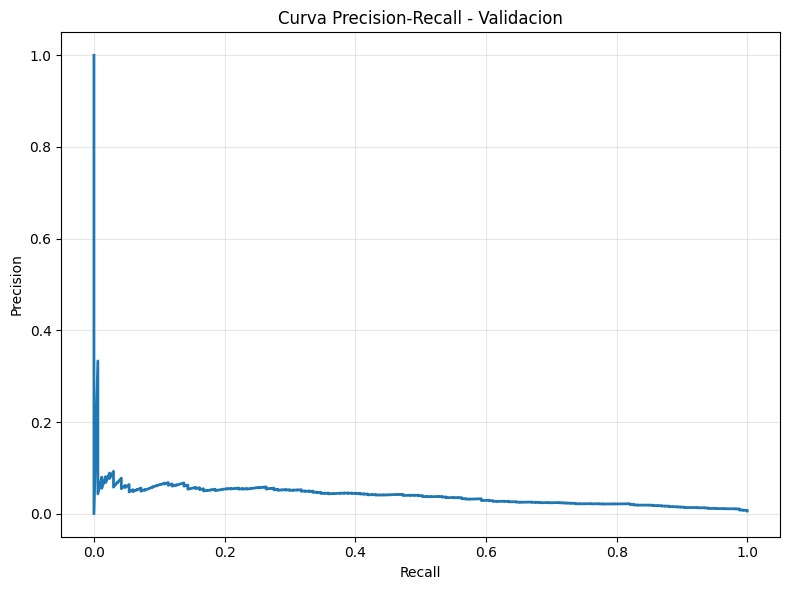

In [29]:
# Vemos la curva de precisión-recall
precision, recall, umbrales_pr = precision_recall_curve(y_validacion, probas_validacion)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Validacion")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "curva_precision_recall_validacion.png"), dpi=200)
plt.show()

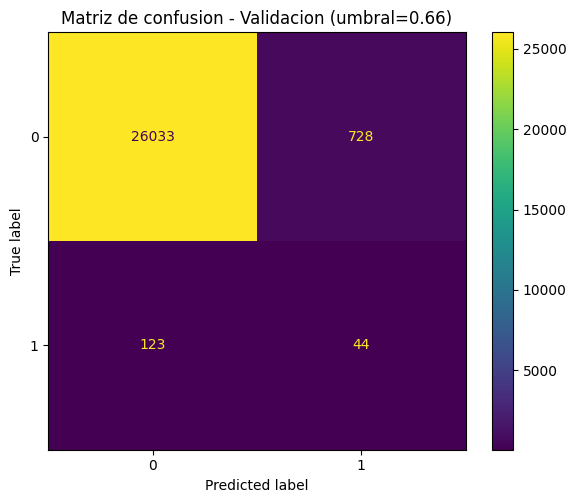

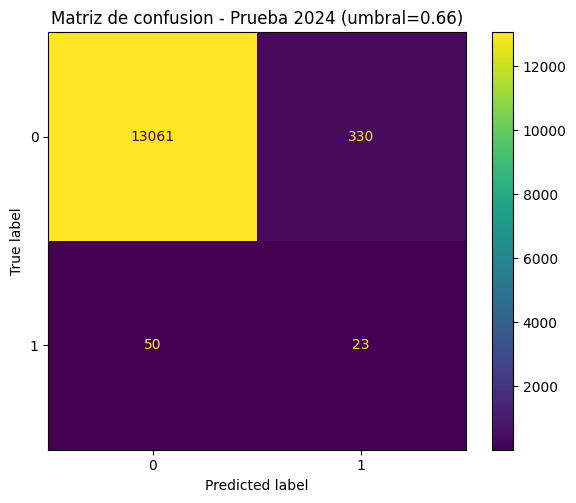

In [30]:
# Metrica de confusion
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_validacion,
    pred_validacion,
    ax=ax,
    values_format="d"
)
ax.set_title(f"Matriz de confusion - Validacion (umbral={umbral_optimo:.2f})")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "matriz_confusion_validacion.png"), dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_prueba,
    pred_prueba,
    ax=ax,
    values_format="d"
)
ax.set_title(f"Matriz de confusion - Prueba 2024 (umbral={umbral_optimo:.2f})")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "matriz_confusion_prueba.png"), dpi=200)
plt.show()


TOP 20 VARIABLES:
                                   variable  importancia
1            precipitacion_media_mensual_mm     0.129137
12            precipitacion_acumulada_3m_mm     0.065798
13                precipitacion_media_3m_mm     0.062432
6                      longitud_drenajes_km     0.040697
14  percentil_95_precipitacion_municipal_mm     0.040282
0                                       mes     0.039529
11                   pendiente_media_grados     0.034359
4                       altitud_municipio_m     0.034330
5                        area_municipio_km2     0.034264
10                        elevacion_media_m     0.032408
34                        area_municipio_ha     0.030195
24                          maiz_no_apta_ha     0.028121
3                       codigo_departamento     0.027650
2                                      anio     0.026458
29                         arroz_no_apta_ha     0.024541
35             proporcion_frontera_agricola     0.023595
30          

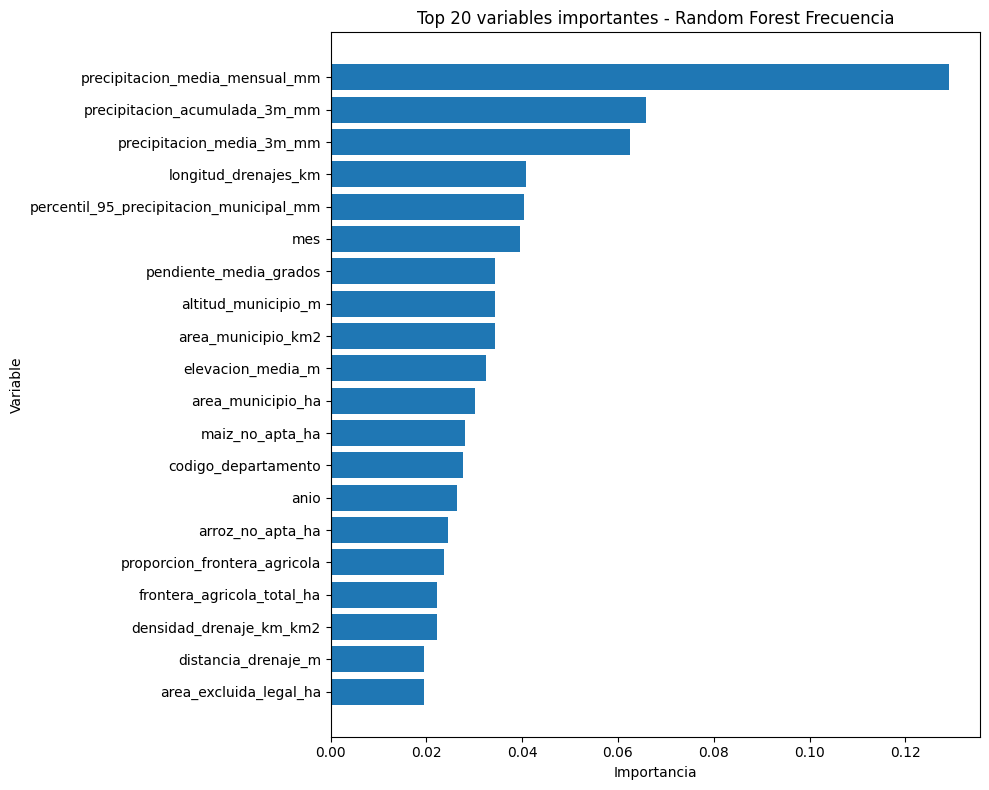

In [31]:
# VEMOS que avriables son las más importantes
rf = modelo_frecuencia.named_steps["rf"]

importancias = pd.DataFrame({
    "variable": columnas_modelo,
    "importancia": rf.feature_importances_
}).sort_values("importancia", ascending=False)

print("\nTOP 20 VARIABLES:")
print(importancias.head(20))

importancias.to_csv(
    os.path.join(CARPETA_SALIDA, "importancia_variables_frecuencia.csv"),
    index=False,
    encoding="utf-8-sig"
)

# Grafico top 20
top20 = importancias.head(20).sort_values("importancia", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top20["variable"], top20["importancia"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 20 variables importantes - Random Forest Frecuencia")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "top20_importancia_frecuencia.png"), dpi=200)
plt.show()

### Modelo neto FR base_frecuencia

#### Modelo 3

In [37]:
from sklearn.ensemble import RandomForestClassifier
# =========================================================
# 1. CONFIGURACION
# =========================================================
RUTA_BASE = "../Data_preparada/Random-forest_LSTMdata/base_frecuencia.csv"
CARPETA_SALIDA = "rf_frecuencia_neto"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

# Cambia aquí el target si quieres
OBJETIVO = "hubo_inundacion_agricola_mes"

GRID_RF = {
    "n_estimators": [300, 500],
    "max_depth": [8, 10, 12, None],
    "min_samples_leaf": [3, 5],
    "min_samples_split": [5, 10],
    "max_features": ["sqrt", "log2", 0.5],
    "class_weight": ["balanced", "balanced_subsample", None]
}

# =========================================================
# 2. CARGA
# =========================================================
df = pd.read_csv(RUTA_BASE)

df["anio"] = pd.to_numeric(df["anio"], errors="coerce")
df["mes"] = pd.to_numeric(df["mes"], errors="coerce")

print("Filas totales:", len(df))
print("Años:", sorted(df["anio"].dropna().unique()))

# =========================================================
# 3. VARIABLES
# =========================================================
columnas_excluir = [
    "codigo_municipio",
    "nombre_municipio",
    "periodo",

    # targets / fuga
    "hubo_inundacion_mes",
    "hubo_inundacion_agricola_mes",
    "numero_eventos_inundacion_mes",
    "numero_eventos_agricolas_mes",
    "hectareas_afectadas_suma_mes",
    "hectareas_afectadas_max_mes",
    "personas_afectadas_suma_mes",
    "familias_afectadas_suma_mes",
    "danio_vivienda_suma_mes",
    "danio_infraestructura_suma_mes",
    "apoyo_fngrd_suma_mes",
    "numero_eventos_con_hectareas_mes",
    "numero_eventos_sin_divipola_mes",
    "indicador_reporte_hectareas_mes",
]

# quita solo el target elegido de la exclusión
columnas_excluir = [c for c in columnas_excluir if c != OBJETIVO]

columnas_modelo = [c for c in df.columns if c not in columnas_excluir]
if OBJETIVO in columnas_modelo:
    columnas_modelo.remove(OBJETIVO)

X = df[columnas_modelo].copy()
y = df[OBJETIVO].astype(int).copy()

print("Variables del modelo:", len(columnas_modelo))
print("Tasa positiva total:", y.mean())

# =========================================================
# 4. SPLIT TEMPORAL
# =========================================================
idx_train = df["anio"] <= 2021
idx_val = (df["anio"] >= 2022) & (df["anio"] <= 2023)
idx_test = df["anio"] == 2024

X_train, y_train = X.loc[idx_train], y.loc[idx_train]
X_val, y_val = X.loc[idx_val], y.loc[idx_val]
X_test, y_test = X.loc[idx_test], y.loc[idx_test]

print("Train:", X_train.shape, "| tasa positiva:", y_train.mean())
print("Val:", X_val.shape, "| tasa positiva:", y_val.mean())
print("Test:", X_test.shape, "| tasa positiva:", y_test.mean())

# =========================================================
# 5. FUNCIONES
# =========================================================
def construir_modelo(config):
    return Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            min_samples_split=config["min_samples_split"],
            max_features=config["max_features"],
            class_weight=config["class_weight"],
            random_state=42,
            n_jobs=-1
        ))
    ])

def metricas_clasificacion(y_real, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "roc_auc": float(roc_auc_score(y_real, y_prob)),
        "pr_auc": float(average_precision_score(y_real, y_prob)),
        "brier": float(brier_score_loss(y_real, y_prob)),
        "precision": float(precision_score(y_real, y_pred, zero_division=0)),
        "recall": float(recall_score(y_real, y_pred, zero_division=0)),
        "f1": float(f1_score(y_real, y_pred, zero_division=0)),
    }

def mejor_umbral_f1(y_real, y_prob):
    mejor = {"umbral": 0.5, "f1": -1, "precision": 0.0, "recall": 0.0}
    for t in np.arange(0.05, 0.96, 0.01):
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_real, y_pred, zero_division=0)
        if f1 > mejor["f1"]:
            mejor = {
                "umbral": float(t),
                "f1": float(f1),
                "precision": float(precision_score(y_real, y_pred, zero_division=0)),
                "recall": float(recall_score(y_real, y_pred, zero_division=0)),
            }
    return mejor

# =========================================================
# 6. TUNING RANDOM FOREST
# =========================================================
combinaciones = list(product(
    GRID_RF["n_estimators"],
    GRID_RF["max_depth"],
    GRID_RF["min_samples_leaf"],
    GRID_RF["min_samples_split"],
    GRID_RF["max_features"],
    GRID_RF["class_weight"]
))

resultados = []
mejor_modelo = None
mejor_config = None
mejor_prob_val = None
mejor_prob_test = None
mejor_score = -np.inf
mejor_brier = np.inf

for i, (n_estimators, max_depth, min_samples_leaf, min_samples_split, max_features, class_weight) in enumerate(combinaciones, start=1):
    config = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "min_samples_split": min_samples_split,
        "max_features": max_features,
        "class_weight": class_weight
    }

    print(f"\nModelo {i}/{len(combinaciones)} -> {config}")

    modelo = construir_modelo(config)
    modelo.fit(X_train, y_train)

    prob_val = modelo.predict_proba(X_val)[:, 1]
    prob_test = modelo.predict_proba(X_test)[:, 1]

    met_val = metricas_clasificacion(y_val, prob_val, threshold=0.5)
    met_test = metricas_clasificacion(y_test, prob_test, threshold=0.5)

    resultados.append({
        **config,
        "val_roc_auc": met_val["roc_auc"],
        "val_pr_auc": met_val["pr_auc"],
        "val_brier": met_val["brier"],
        "val_precision_05": met_val["precision"],
        "val_recall_05": met_val["recall"],
        "val_f1_05": met_val["f1"],
        "test_roc_auc": met_test["roc_auc"],
        "test_pr_auc": met_test["pr_auc"],
        "test_brier": met_test["brier"],
        "test_precision_05": met_test["precision"],
        "test_recall_05": met_test["recall"],
        "test_f1_05": met_test["f1"],
    })

    print("Validación:", met_val)
    print("Prueba:", met_test)

    # criterio principal: mayor PR-AUC en validación
    # desempate: menor Brier en validación
    if (
        met_val["pr_auc"] > mejor_score
        or (np.isclose(met_val["pr_auc"], mejor_score) and met_val["brier"] < mejor_brier)
    ):
        mejor_modelo = modelo
        mejor_config = config
        mejor_prob_val = prob_val
        mejor_prob_test = prob_test
        mejor_score = met_val["pr_auc"]
        mejor_brier = met_val["brier"]

# =========================================================
# 7. RESULTADOS FINALES
# =========================================================
df_resultados = pd.DataFrame(resultados).sort_values(
    ["val_pr_auc", "val_brier"],
    ascending=[False, True]
)

df_resultados.to_csv(
    os.path.join(CARPETA_SALIDA, "resultados_tuning_rf_frecuencia.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("\n=== MEJOR CONFIGURACION ===")
print(mejor_config)

umbral_optimo = mejor_umbral_f1(y_val, mejor_prob_val)["umbral"]

met_val_final = metricas_clasificacion(y_val, mejor_prob_val, threshold=umbral_optimo)
met_test_final = metricas_clasificacion(y_test, mejor_prob_test, threshold=umbral_optimo)

print("\n=== UMBRAL OPTIMO EN VALIDACION ===")
print(umbral_optimo)

print("\n=== VALIDACION FINAL ===")
print(met_val_final)
print("Matriz validación:")
print(confusion_matrix(y_val, (mejor_prob_val >= umbral_optimo).astype(int)))

print("\n=== PRUEBA FINAL ===")
print(met_test_final)
print("Matriz prueba:")
print(confusion_matrix(y_test, (mejor_prob_test >= umbral_optimo).astype(int)))

print("\n=== REPORTE CLASIFICACION PRUEBA ===")
print(classification_report(y_test, (mejor_prob_test >= umbral_optimo).astype(int), zero_division=0))

# =========================================================
# 8. IMPORTANCIA DE VARIABLES
# =========================================================
rf = mejor_modelo.named_steps["rf"]
importancias = pd.DataFrame({
    "variable": columnas_modelo,
    "importancia": rf.feature_importances_
}).sort_values("importancia", ascending=False)

print("\n=== TOP 20 VARIABLES ===")
print(importancias.head(20))

importancias.to_csv(
    os.path.join(CARPETA_SALIDA, "importancia_variables_rf_frecuencia.csv"),
    index=False,
    encoding="utf-8-sig"
)

top20 = importancias.head(20).sort_values("importancia", ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(top20["variable"], top20["importancia"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 20 variables - Random Forest frecuencia")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "top20_importancia_rf_frecuencia.png"), dpi=200)
plt.close()

# =========================================================
# 9. GUARDAR MODELO
# =========================================================
joblib.dump(
    mejor_modelo,
    os.path.join(CARPETA_SALIDA, "mejor_modelo_rf_frecuencia.joblib")
)

metadatos = {
    "objetivo": OBJETIVO,
    "mejor_configuracion": mejor_config,
    "umbral_optimo_validacion": float(umbral_optimo),
    "metricas_validacion_final": met_val_final,
    "metricas_prueba_final": met_test_final,
    "columnas_modelo": columnas_modelo
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_rf_frecuencia.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

Filas totales: 199716
Años: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Variables del modelo: 45
Tasa positiva total: 0.003725289911674578
Train: (159324, 45) | tasa positiva: 0.0031633652180462456
Val: (26928, 45) | tasa positiva: 0.006201723113487819
Test: (13464, 45) | tasa positiva: 0.005421865715983363

Modelo 1/288 -> {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}
Validación: {'roc_auc': 0.9134423876733659, 'pr_auc': 0.09442522951275259, 'brier': 0.08744656379652997, 'precision': 0.0473664266767715, 'recall': 0.7485029940119761, 'f1': 0.08909479686386315}
Prueba: {'roc_auc': 0.9489280778441459, 'pr_auc': 0.143325618951544, 'brier': 0.07740374629123889, 'precision': 0.05185185185185185, 'recall': 0.

MemoryError: Unable to allocate 1.22 MiB for an array with shape (159324,) and data type int64

## Severidad

In [33]:
# Cargamnos la base
base_severidad = pd.read_csv("../Data_preparada/Random-forest_LSTMdata/base_severidad.csv")

Vemos la información de dataset

In [34]:
info_data(base_severidad)

El dataset está conformado por:  (433, 62) Filas/Columnas.
<class 'pandas.DataFrame'>
RangeIndex: 433 entries, 0 to 432
Data columns (total 62 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   codigo_municipio                         433 non-null    int64  
 1   mes                                      433 non-null    int64  
 2   precipitacion_media_mensual_mm           433 non-null    float64
 3   anio                                     433 non-null    int64  
 4   periodo                                  433 non-null    str    
 5   nombre_municipio                         433 non-null    str    
 6   codigo_departamento                      433 non-null    int64  
 7   altitud_municipio_m                      433 non-null    int64  
 8   area_municipio_km2                       433 non-null    float64
 9   longitud_drenajes_km                     433 non-null    float64
 10  de

In [35]:
# Transformamos la variable a logaritmica
base_severidad["log_hectareas_afectadas_suma_mes"] = np.log1p(
    base_severidad["hectareas_afectadas_suma_mes"]
)

# Variable objetivo
objetivo = 'log_hectareas_afectadas_suma_mes'

In [36]:
# Columnas a excluir
columnas_excluir = ["codigo_municipio", "nombre_municipio", "periodo",

    # targets / fuga
    "hubo_inundacion_mes",
    "hubo_inundacion_agricola_mes",
    "numero_eventos_inundacion_mes",
    "numero_eventos_agricolas_mes",
    "hectareas_afectadas_suma_mes",
    "hectareas_afectadas_max_mes",
    "log_hectareas_afectadas_suma_mes",
    "personas_afectadas_suma_mes",
    "familias_afectadas_suma_mes",
    "danio_vivienda_suma_mes",
    "danio_infraestructura_suma_mes",
    "apoyo_fngrd_suma_mes",
    "numero_eventos_con_hectareas_mes",
    "numero_eventos_sin_divipola_mes",
    "indicador_reporte_hectareas_mes",
    "tasa_afectacion_agricola"
]

columnas_modelo = [c for c in base_severidad.columns if c not in columnas_excluir]

x_severidad = base_severidad[columnas_modelo].copy()
y_severidad = base_severidad[objetivo].copy()

In [37]:
info_data(x_severidad)

El dataset está conformado por:  (433, 44) Filas/Columnas.
<class 'pandas.DataFrame'>
RangeIndex: 433 entries, 0 to 432
Data columns (total 44 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   mes                                      433 non-null    int64  
 1   precipitacion_media_mensual_mm           433 non-null    float64
 2   anio                                     433 non-null    int64  
 3   codigo_departamento                      433 non-null    int64  
 4   altitud_municipio_m                      433 non-null    int64  
 5   area_municipio_km2                       433 non-null    float64
 6   longitud_drenajes_km                     433 non-null    float64
 7   densidad_drenaje_km_km2                  433 non-null    float64
 8   distancia_drenaje_m                      433 non-null    float64
 9   proporcion_humedales                     433 non-null    float64
 10  el

Ya habiendo transformado y asignado las variables ya designadas como la variable objetivo y predictoras se pasa a reconstruir el modelo.

### Data preparation

Esta sección de preparación de datos ya fue realizada en los scripts llamados "Preparacion_...", sin embargo, está dispuesta en dado caso que se necesite preparar para mejorar el modelo. 

### Modelos

#### Modelo 1

In [38]:
train_idx = base_severidad["anio"] <= 2021
val_idx = (base_severidad["anio"] >= 2022) & (base_severidad["anio"] <= 2023)
test_idx = base_severidad["anio"] == 2024

X_train, y_train = x_severidad.loc[train_idx], y_severidad.loc[train_idx]
X_val, y_val = x_severidad.loc[val_idx], y_severidad.loc[val_idx]
X_test, y_test = x_severidad.loc[test_idx], y_severidad.loc[test_idx]

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (193, 44)
Val: (167, 44)
Test: (73, 44)


In [39]:
modelo_severidad = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=10,
        min_samples_split=20,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

modelo_severidad.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputador', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fea

In [40]:
# Validación
pred_val = modelo_severidad.predict(X_val)

rmse_val = np.sqrt(mean_squared_error(y_val, pred_val))
mae_val = mean_absolute_error(y_val, pred_val)
r2_val = r2_score(y_val, pred_val)

print("\nVALIDACION:")
print("RMSE:", rmse_val)
print("MAE:", mae_val)
print("R2:", r2_val)


VALIDACION:
RMSE: 2.654257528972757
MAE: 2.325914980959353
R2: -0.011914227072363115


In [41]:
# Prueba finall
pred_test = modelo_severidad.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
mae_test = mean_absolute_error(y_test, pred_test)
r2_test = r2_score(y_test, pred_test)

print("\nPRUEBA 2024:")
print("RMSE:", rmse_test)
print("MAE:", mae_test)
print("R2:", r2_test)


PRUEBA 2024:
RMSE: 3.0670013097076754
MAE: 2.6894283461793567
R2: 0.0008800769595921354


In [42]:
# Variables más importantes
rf = modelo_severidad.named_steps["rf"]
importancias = pd.DataFrame({
    "variable": columnas_modelo,
    "importancia": rf.feature_importances_
}).sort_values("importancia", ascending=False)

print("\nTOP 20 VARIABLES")
print(importancias.head(20))


TOP 20 VARIABLES
                         variable  importancia
6            longitud_drenajes_km     0.050290
10              elevacion_media_m     0.044943
7         densidad_drenaje_km_km2     0.041945
26          arroz_aptitud_baja_ha     0.037596
11         pendiente_media_grados     0.036934
39  proporcion_arroz_aptitud_alta     0.034476
21           maiz_aptitud_baja_ha     0.033286
31         area_excluida_legal_ha     0.033228
5              area_municipio_km2     0.032921
27         arroz_aptitud_media_ha     0.031738
22          maiz_aptitud_media_ha     0.031648
25          arroz_aptitud_alta_ha     0.031581
34              area_municipio_ha     0.030212
24                maiz_no_apta_ha     0.029473
8             distancia_drenaje_m     0.028437
13      precipitacion_media_3m_mm     0.027659
17              maiz_produccion_t     0.024076
3             codigo_departamento     0.023922
35   proporcion_frontera_agricola     0.023562
4             altitud_municipio_m     0.02

#### Modelo 2

Filas totales severidad: 202
Años: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Variables del modelo: 44
Train: (86, 44)
Val: (76, 44)
Test: (40, 44)

Evaluando: rf_sev_1
Validación: {'rmse': 2.0488350465338216, 'mae': 1.6763440065265398, 'r2': 0.016160857711723486, 'spearman': 0.27854350216739365}

Evaluando: rf_sev_2
Validación: {'rmse': 2.047595809804869, 'mae': 1.6765221785510434, 'r2': 0.0173506468882072, 'spearman': 0.28185249669512963}

Evaluando: rf_sev_3
Validación: {'rmse': 2.0931121079276878, 'mae': 1.7008425828408693, 'r2': -0.026821818427300137, 'spearman': 0.25777340841685265}

=== Mejor configuración ===
{'nombre': 'rf_sev_2', 'n_estimators': 500, 'max_depth': 12, 'min_samples_leaf': 10, 'min_samples_split': 20, 'max_features': 'sqrt'}

=== VALIDACION FINAL ===
{'rmse': 2.047595809804869, 'mae': 1.6765221785510434, 'r2': 0.0173506468882072, 'spearman': 0.28185249669512963}

=== PRUEBA FINAL 2024 ===
{'rmse': 2.358204937

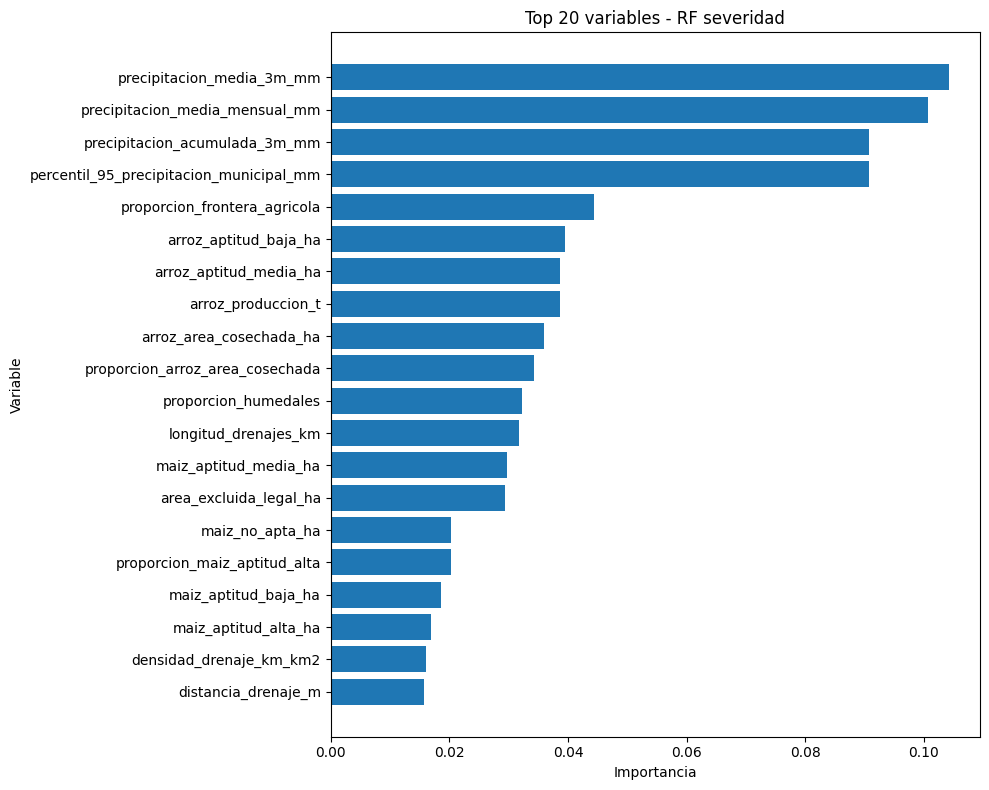

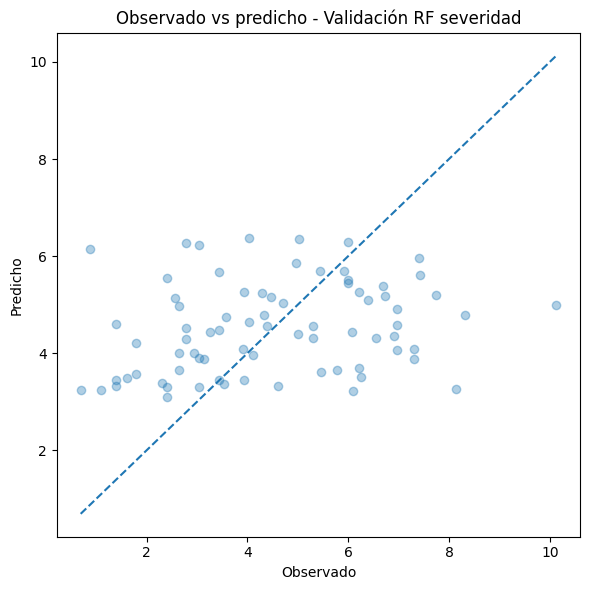

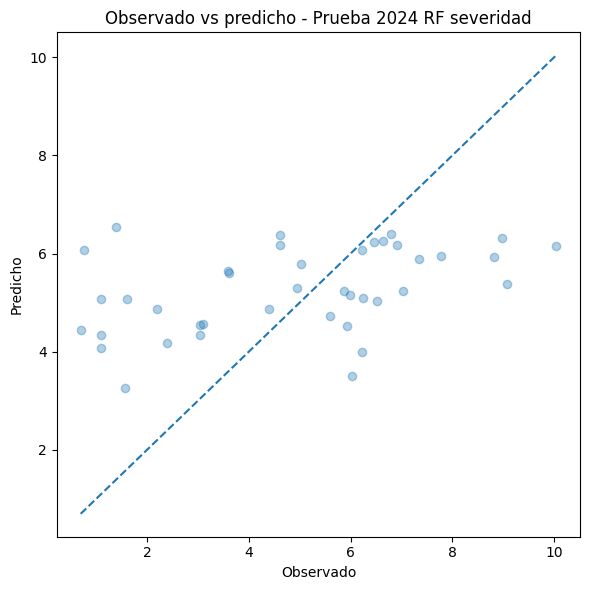


Proceso finalizado: salidas_rf_severidad


In [43]:
# =========================================================
# CONFIGURACION
# =========================================================
RUTA_BASE = "../Data_preparada/Random-forest_LSTMdata/base_severidad.csv"
CARPETA_SALIDA = "salidas_rf_severidad"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

OBJETIVO_BASE = "hectareas_afectadas_suma_mes"
OBJETIVO_MODELO = "log_hectareas_afectadas"

# grilla corta pero útil
GRILLA_MODELOS = [
    {
        "nombre": "rf_sev_1",
        "n_estimators": 300,
        "max_depth": 10,
        "min_samples_leaf": 10,
        "min_samples_split": 20,
        "max_features": "sqrt"
    },
    {
        "nombre": "rf_sev_2",
        "n_estimators": 500,
        "max_depth": 12,
        "min_samples_leaf": 10,
        "min_samples_split": 20,
        "max_features": "sqrt"
    },
    {
        "nombre": "rf_sev_3",
        "n_estimators": 500,
        "max_depth": 16,
        "min_samples_leaf": 5,
        "min_samples_split": 10,
        "max_features": "sqrt"
    }
]

# =========================================================
# CARGA
# =========================================================
df = pd.read_csv(RUTA_BASE)

df["anio"] = pd.to_numeric(df["anio"], errors="coerce")
df["mes"] = pd.to_numeric(df["mes"], errors="coerce")

# solo positivos para severidad
df = df[df[OBJETIVO_BASE] > 0].copy()
df[OBJETIVO_MODELO] = np.log1p(df[OBJETIVO_BASE])

print("Filas totales severidad:", len(df))
print("Años:", sorted(df["anio"].dropna().unique()))

# =========================================================
# VARIABLES
# =========================================================
columnas_excluir = [
    # identificacion
    "codigo_municipio",
    "nombre_municipio",
    "periodo",

    # targets / fuga
    "hubo_inundacion_mes",
    "hubo_inundacion_agricola_mes",
    "numero_eventos_inundacion_mes",
    "numero_eventos_agricolas_mes",
    "hectareas_afectadas_suma_mes",
    "hectareas_afectadas_max_mes",
    "log_hectareas_afectadas",
    "personas_afectadas_suma_mes",
    "familias_afectadas_suma_mes",
    "danio_vivienda_suma_mes",
    "danio_infraestructura_suma_mes",
    "apoyo_fngrd_suma_mes",
    "numero_eventos_con_hectareas_mes",
    "numero_eventos_sin_divipola_mes",
    "indicador_reporte_hectareas_mes",
    "tasa_afectacion_agricola",
]

columnas_modelo = [c for c in df.columns if c not in columnas_excluir]

X = df[columnas_modelo].copy()
y = df[OBJETIVO_MODELO].copy()

print("Variables del modelo:", len(columnas_modelo))

# =========================================================
# SPLIT TEMPORAL
# =========================================================
idx_train = df["anio"] <= 2021
idx_val = (df["anio"] >= 2022) & (df["anio"] <= 2023)
idx_test = df["anio"] == 2024

X_train, y_train = X.loc[idx_train], y.loc[idx_train]
X_val, y_val = X.loc[idx_val], y.loc[idx_val]
X_test, y_test = X.loc[idx_test], y.loc[idx_test]

meta_val = df.loc[idx_val, ["codigo_municipio", "anio", "mes"]].copy()
meta_test = df.loc[idx_test, ["codigo_municipio", "anio", "mes"]].copy()

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# =========================================================
# FUNCIONES
# =========================================================
def construir_modelo(config):
    return Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("rf", RandomForestRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            min_samples_split=config["min_samples_split"],
            max_features=config["max_features"],
            random_state=42,
            n_jobs=-1
        ))
    ])

def metricas_regresion(y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    try:
        spear = spearmanr(y_real, y_pred).correlation
    except:
        spear = np.nan

    return {
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
        "spearman": None if pd.isna(spear) else float(spear)
    }

def graficar_obs_pred(y_real, y_pred, titulo, ruta):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_real, y_pred, alpha=0.35)
    mn = min(np.min(y_real), np.min(y_pred))
    mx = max(np.max(y_real), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Observado")
    plt.ylabel("Predicho")
    plt.title(titulo)
    plt.tight_layout()
    plt.savefig(ruta, dpi=200)
    plt.show()

# =========================================================
# TUNING SIMPLE
# =========================================================
resultados = []
mejor_modelo = None
mejor_config = None
mejor_score = np.inf  # menor RMSE validación

for config in GRILLA_MODELOS:
    print(f"\nEvaluando: {config['nombre']}")
    modelo = construir_modelo(config)
    modelo.fit(X_train, y_train)

    pred_val = modelo.predict(X_val)
    met_val = metricas_regresion(y_val, pred_val)

    resultados.append({
        "modelo": config["nombre"],
        **met_val
    })

    print("Validación:", met_val)

    if met_val["rmse"] < mejor_score:
        mejor_score = met_val["rmse"]
        mejor_modelo = modelo
        mejor_config = config

df_resultados = pd.DataFrame(resultados).sort_values("rmse")
df_resultados.to_csv(
    os.path.join(CARPETA_SALIDA, "comparacion_modelos_rf_severidad.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("\n=== Mejor configuración ===")
print(mejor_config)

# =========================================================
# EVALUACION FINAL
# =========================================================
pred_val = mejor_modelo.predict(X_val)
pred_test = mejor_modelo.predict(X_test)

met_val = metricas_regresion(y_val, pred_val)
met_test = metricas_regresion(y_test, pred_test)

print("\n=== VALIDACION FINAL ===")
print(met_val)

print("\n=== PRUEBA FINAL 2024 ===")
print(met_test)

# =========================================================
# IMPORTANCIA DE VARIABLES
# =========================================================
rf = mejor_modelo.named_steps["rf"]
importancias = pd.DataFrame({
    "variable": columnas_modelo,
    "importancia": rf.feature_importances_
}).sort_values("importancia", ascending=False)

print("\n=== TOP 20 VARIABLES ===")
print(importancias.head(20))

importancias.to_csv(
    os.path.join(CARPETA_SALIDA, "importancia_variables_rf_severidad.csv"),
    index=False,
    encoding="utf-8-sig"
)

top20 = importancias.head(20).sort_values("importancia", ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(top20["variable"], top20["importancia"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 20 variables - RF severidad")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "top20_importancia_rf_severidad.png"), dpi=200)
plt.show()

# =========================================================
# GRAFICOS OBS vs PRED
# =========================================================
graficar_obs_pred(
    y_val.values,
    pred_val,
    "Observado vs predicho - Validación RF severidad",
    os.path.join(CARPETA_SALIDA, "obs_vs_pred_validacion_rf_severidad.png")
)

graficar_obs_pred(
    y_test.values,
    pred_test,
    "Observado vs predicho - Prueba 2024 RF severidad",
    os.path.join(CARPETA_SALIDA, "obs_vs_pred_prueba_rf_severidad.png")
)

# =========================================================
# GUARDAR MODELO Y PREDICCIONES
# =========================================================
joblib.dump(
    mejor_modelo,
    os.path.join(CARPETA_SALIDA, "mejor_modelo_rf_severidad.joblib")
)

pred_val_df = meta_val.copy()
pred_val_df["observado_log"] = y_val.values
pred_val_df["predicho_log"] = pred_val
pred_val_df["observado_ha"] = np.expm1(y_val.values)
pred_val_df["predicho_ha"] = np.expm1(pred_val)

pred_test_df = meta_test.copy()
pred_test_df["observado_log"] = y_test.values
pred_test_df["predicho_log"] = pred_test
pred_test_df["observado_ha"] = np.expm1(y_test.values)
pred_test_df["predicho_ha"] = np.expm1(pred_test)

pred_val_df.to_csv(
    os.path.join(CARPETA_SALIDA, "predicciones_validacion_rf_severidad.csv"),
    index=False,
    encoding="utf-8-sig"
)

pred_test_df.to_csv(
    os.path.join(CARPETA_SALIDA, "predicciones_prueba_rf_severidad.csv"),
    index=False,
    encoding="utf-8-sig"
)

# =========================================================
# METADATOS
# =========================================================
metadatos = {
    "objetivo_base": OBJETIVO_BASE,
    "objetivo_modelo": OBJETIVO_MODELO,
    "mejor_configuracion": mejor_config,
    "metricas_validacion_final": met_val,
    "metricas_prueba_final": met_test,
    "columnas_modelo": columnas_modelo
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_rf_severidad.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

#### Modelo 3

Filas totales severidad relativa: 194
Años: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Variables del modelo: 44
Train: (82, 44)
Val: (73, 44)
Test: (39, 44)

Evaluando: rf_rel_1
Validación: {'rmse': 0.38543483254545075, 'mae': 0.34311498710252464, 'r2': 0.1249088259179878, 'spearman': 0.4271418101840983}

Evaluando: rf_rel_2
Validación: {'rmse': 0.3845803476424733, 'mae': 0.3420166145342821, 'r2': 0.12878456974807284, 'spearman': 0.4252633425300939}

Evaluando: rf_rel_3
Validación: {'rmse': 0.38997550678488396, 'mae': 0.339744035371051, 'r2': 0.10416908549709325, 'spearman': 0.4149240081700369}

=== Mejor configuración ===
{'nombre': 'rf_rel_2', 'n_estimators': 500, 'max_depth': 12, 'min_samples_leaf': 10, 'min_samples_split': 20, 'max_features': 'sqrt'}

=== VALIDACION FINAL ===
{'rmse': 0.3845803476424733, 'mae': 0.3420166145342822, 'r2': 0.12878456974807284, 'spearman': 0.4252633425300939}

=== PRUEBA FINAL 2024 ===
{'rmse': 0.35

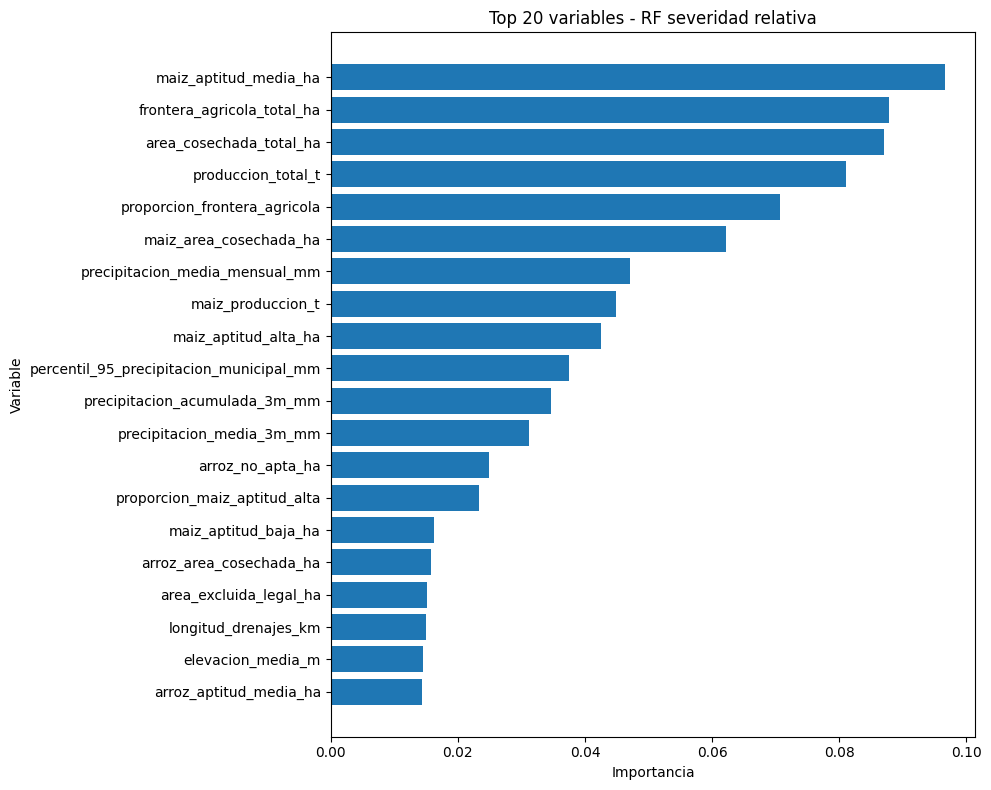

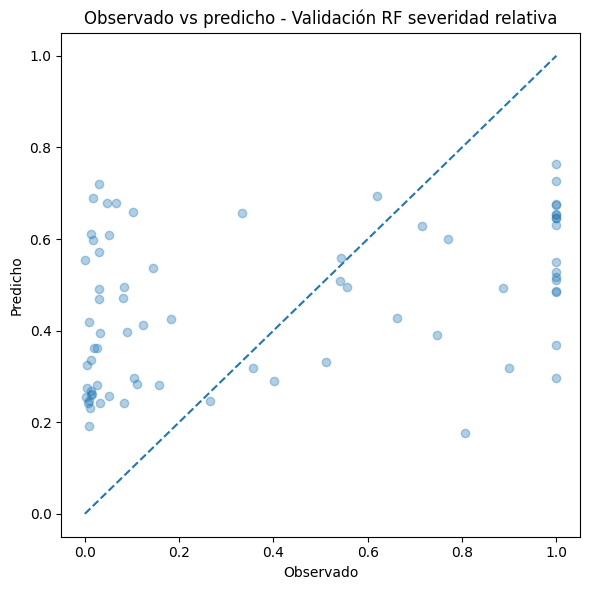

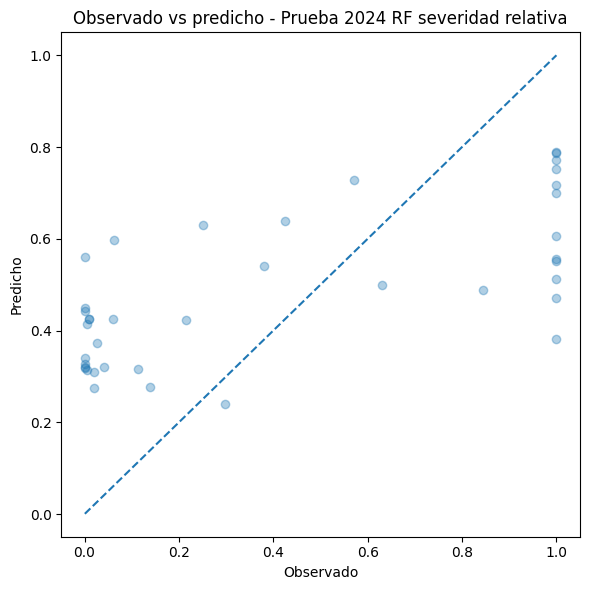


Proceso finalizado: salidas_rf_severidad_relativa


In [44]:
# =========================================================
# CONFIGURACION
# =========================================================
RUTA_BASE = "../Data_preparada/Random-forest_LSTMdata/base_severidad.csv"
CARPETA_SALIDA = "salidas_rf_severidad_relativa"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

OBJETIVO = "tasa_afectacion_agricola"

GRILLA_MODELOS = [
    {
        "nombre": "rf_rel_1",
        "n_estimators": 300,
        "max_depth": 10,
        "min_samples_leaf": 10,
        "min_samples_split": 20,
        "max_features": "sqrt"
    },
    {
        "nombre": "rf_rel_2",
        "n_estimators": 500,
        "max_depth": 12,
        "min_samples_leaf": 10,
        "min_samples_split": 20,
        "max_features": "sqrt"
    },
    {
        "nombre": "rf_rel_3",
        "n_estimators": 500,
        "max_depth": 16,
        "min_samples_leaf": 5,
        "min_samples_split": 10,
        "max_features": "sqrt"
    }
]

# =========================================================
# CARGA
# =========================================================
df = pd.read_csv(RUTA_BASE)

df["anio"] = pd.to_numeric(df["anio"], errors="coerce")
df["mes"] = pd.to_numeric(df["mes"], errors="coerce")

# filtros de severidad relativa
df = df[
    (df["indicador_eva_observada_fuente"] == 1) &
    (df["area_cosechada_total_ha"] > 0) &
    (df[OBJETIVO].notna()) &
    (df[OBJETIVO] > 0) &
    (df[OBJETIVO] <= 1)
].copy()

print("Filas totales severidad relativa:", len(df))
print("Años:", sorted(df["anio"].dropna().unique()))

# opcional: winsorización ligera para estabilizar extremos
p99 = df[OBJETIVO].quantile(0.99)
df["tasa_afectacion_agricola_cap"] = np.minimum(df[OBJETIVO], p99)

# =========================================================
# VARIABLES
# =========================================================
columnas_excluir = [
    "codigo_municipio",
    "nombre_municipio",
    "periodo",

    # targets / fuga
    "hubo_inundacion_mes",
    "hubo_inundacion_agricola_mes",
    "numero_eventos_inundacion_mes",
    "numero_eventos_agricolas_mes",
    "hectareas_afectadas_suma_mes",
    "hectareas_afectadas_max_mes",
    "personas_afectadas_suma_mes",
    "familias_afectadas_suma_mes",
    "danio_vivienda_suma_mes",
    "danio_infraestructura_suma_mes",
    "apoyo_fngrd_suma_mes",
    "numero_eventos_con_hectareas_mes",
    "numero_eventos_sin_divipola_mes",
    "indicador_reporte_hectareas_mes",

    # target relativo
    "tasa_afectacion_agricola",
    "tasa_afectacion_agricola_cap",
]

columnas_modelo = [c for c in df.columns if c not in columnas_excluir]

X = df[columnas_modelo].copy()
y = df["tasa_afectacion_agricola_cap"].copy()

print("Variables del modelo:", len(columnas_modelo))

# =========================================================
# SPLIT TEMPORAL
# =========================================================
idx_train = df["anio"] <= 2021
idx_val = (df["anio"] >= 2022) & (df["anio"] <= 2023)
idx_test = df["anio"] == 2024

X_train, y_train = X.loc[idx_train], y.loc[idx_train]
X_val, y_val = X.loc[idx_val], y.loc[idx_val]
X_test, y_test = X.loc[idx_test], y.loc[idx_test]

meta_val = df.loc[idx_val, ["codigo_municipio", "anio", "mes"]].copy()
meta_test = df.loc[idx_test, ["codigo_municipio", "anio", "mes"]].copy()

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# =========================================================
# FUNCIONES
# =========================================================
def construir_modelo(config):
    return Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("rf", RandomForestRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            min_samples_split=config["min_samples_split"],
            max_features=config["max_features"],
            random_state=42,
            n_jobs=-1
        ))
    ])

def metricas_regresion(y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    try:
        spear = spearmanr(y_real, y_pred).correlation
    except:
        spear = np.nan

    return {
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
        "spearman": None if pd.isna(spear) else float(spear)
    }

def graficar_obs_pred(y_real, y_pred, titulo, ruta):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_real, y_pred, alpha=0.35)
    mn = min(np.min(y_real), np.min(y_pred))
    mx = max(np.max(y_real), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Observado")
    plt.ylabel("Predicho")
    plt.title(titulo)
    plt.tight_layout()
    plt.savefig(ruta, dpi=200)
    plt.show()

# =========================================================
# TUNING
# =========================================================
resultados = []
mejor_modelo = None
mejor_config = None
mejor_score = np.inf

for config in GRILLA_MODELOS:
    print(f"\nEvaluando: {config['nombre']}")
    modelo = construir_modelo(config)
    modelo.fit(X_train, y_train)

    pred_val = modelo.predict(X_val)
    met_val = metricas_regresion(y_val, pred_val)

    resultados.append({
        "modelo": config["nombre"],
        **met_val
    })

    print("Validación:", met_val)

    if met_val["rmse"] < mejor_score:
        mejor_score = met_val["rmse"]
        mejor_modelo = modelo
        mejor_config = config

df_resultados = pd.DataFrame(resultados).sort_values("rmse")
df_resultados.to_csv(
    os.path.join(CARPETA_SALIDA, "comparacion_modelos_rf_severidad_relativa.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("\n=== Mejor configuración ===")
print(mejor_config)

# =========================================================
# EVALUACION FINAL
# =========================================================
pred_val = mejor_modelo.predict(X_val)
pred_test = mejor_modelo.predict(X_test)

met_val = metricas_regresion(y_val, pred_val)
met_test = metricas_regresion(y_test, pred_test)

print("\n=== VALIDACION FINAL ===")
print(met_val)

print("\n=== PRUEBA FINAL 2024 ===")
print(met_test)

# =========================================================
# IMPORTANCIA DE VARIABLES
# =========================================================
rf = mejor_modelo.named_steps["rf"]
importancias = pd.DataFrame({
    "variable": columnas_modelo,
    "importancia": rf.feature_importances_
}).sort_values("importancia", ascending=False)

print("\n=== TOP 20 VARIABLES ===")
print(importancias.head(20))

importancias.to_csv(
    os.path.join(CARPETA_SALIDA, "importancia_variables_rf_severidad_relativa.csv"),
    index=False,
    encoding="utf-8-sig"
)

top20 = importancias.head(20).sort_values("importancia", ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(top20["variable"], top20["importancia"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 20 variables - RF severidad relativa")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "top20_importancia_rf_severidad_relativa.png"), dpi=200)
plt.show()

# =========================================================
# GRAFICOS OBS vs PRED
# =========================================================
graficar_obs_pred(
    y_val.values,
    pred_val,
    "Observado vs predicho - Validación RF severidad relativa",
    os.path.join(CARPETA_SALIDA, "obs_vs_pred_validacion_rf_severidad_relativa.png")
)

graficar_obs_pred(
    y_test.values,
    pred_test,
    "Observado vs predicho - Prueba 2024 RF severidad relativa",
    os.path.join(CARPETA_SALIDA, "obs_vs_pred_prueba_rf_severidad_relativa.png")
)

# =========================================================
# GUARDAR MODELO Y PREDICCIONES
# =========================================================
joblib.dump(
    mejor_modelo,
    os.path.join(CARPETA_SALIDA, "mejor_modelo_rf_severidad_relativa.joblib")
)

pred_val_df = meta_val.copy()
pred_val_df["observado_tasa"] = y_val.values
pred_val_df["predicho_tasa"] = pred_val

pred_test_df = meta_test.copy()
pred_test_df["observado_tasa"] = y_test.values
pred_test_df["predicho_tasa"] = pred_test

pred_val_df.to_csv(
    os.path.join(CARPETA_SALIDA, "predicciones_validacion_rf_severidad_relativa.csv"),
    index=False,
    encoding="utf-8-sig"
)

pred_test_df.to_csv(
    os.path.join(CARPETA_SALIDA, "predicciones_prueba_rf_severidad_relativa.csv"),
    index=False,
    encoding="utf-8-sig"
)

# =========================================================
# METADATOS
# =========================================================
metadatos = {
    "objetivo": OBJETIVO,
    "objetivo_modelado": "tasa_afectacion_agricola_cap",
    "mejor_configuracion": mejor_config,
    "metricas_validacion_final": met_val,
    "metricas_prueba_final": met_test,
    "columnas_modelo": columnas_modelo,
    "p99_cap": float(p99)
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_rf_severidad_relativa.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

#### Modelo 4

Filas totales severidad relativa: 194
Años: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Variables del modelo: 44
Train: (82, 44)
Val: (73, 44)
Test: (39, 44)

Evaluando modelo: rf_rel
Validación: {'rmse': 0.3845803476424733, 'mae': 0.3420166145342821, 'r2': 0.12878456974807284, 'spearman': 0.4252633425300939}
Prueba: {'rmse': 0.3517853051998666, 'mae': 0.32768641078115596, 'r2': 0.34105713727606424, 'spearman': 0.6029201130233873}

Evaluando modelo: extra_trees_rel
Validación: {'rmse': 0.3958615194459583, 'mae': 0.3582645831195264, 'r2': 0.07692294054023163, 'spearman': 0.3647487399242345}
Prueba: {'rmse': 0.36223282941423507, 'mae': 0.3360565654140663, 'r2': 0.30133661058349803, 'spearman': 0.5463257378486196}

Evaluando modelo: gbr_rel
Validación: {'rmse': 0.43438623361879336, 'mae': 0.33047616833660887, 'r2': -0.11148470286944412, 'spearman': 0.41721633432972455}
Prueba: {'rmse': 0.31333954564334365, 'mae': 0.2637065664056177, 'r2

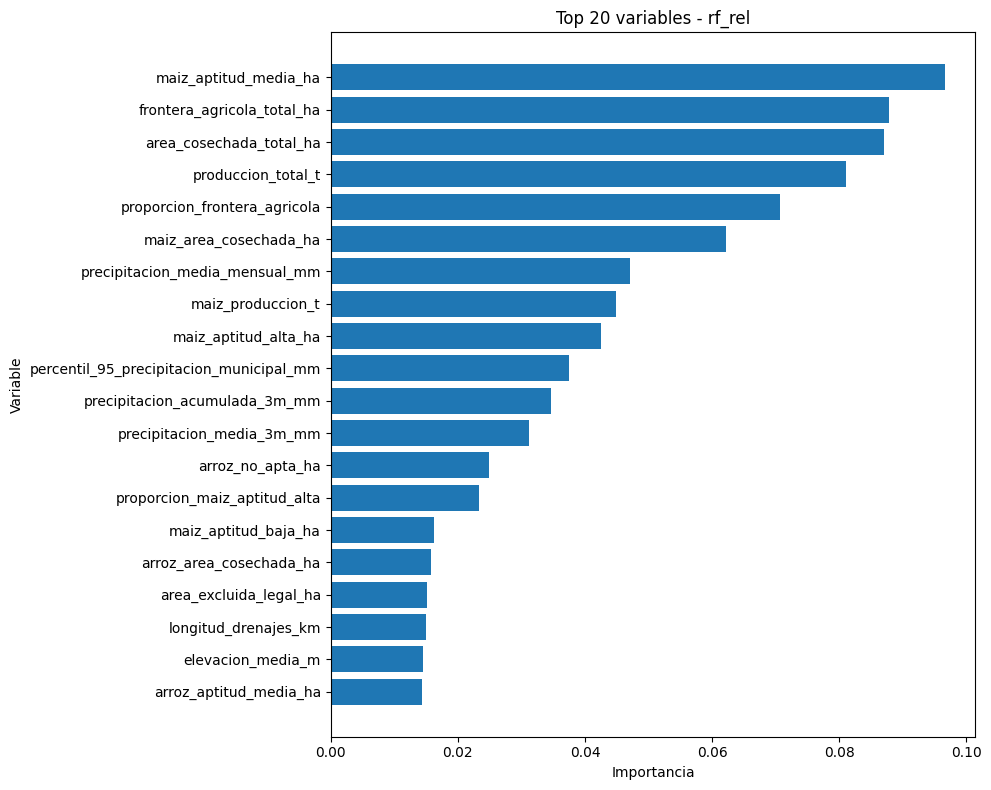

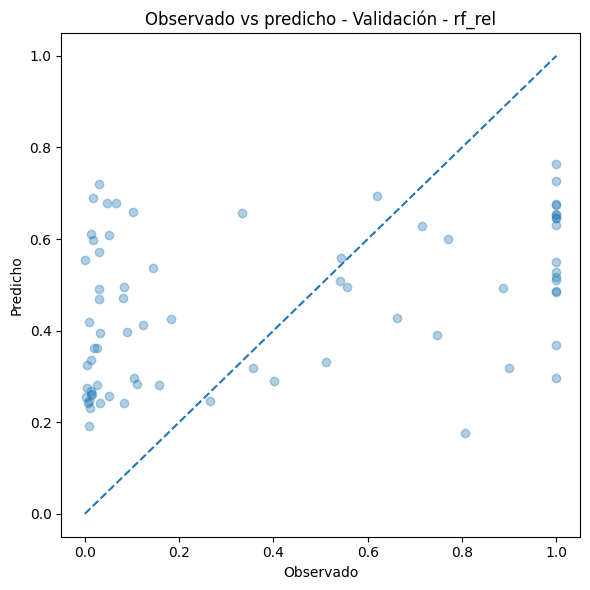

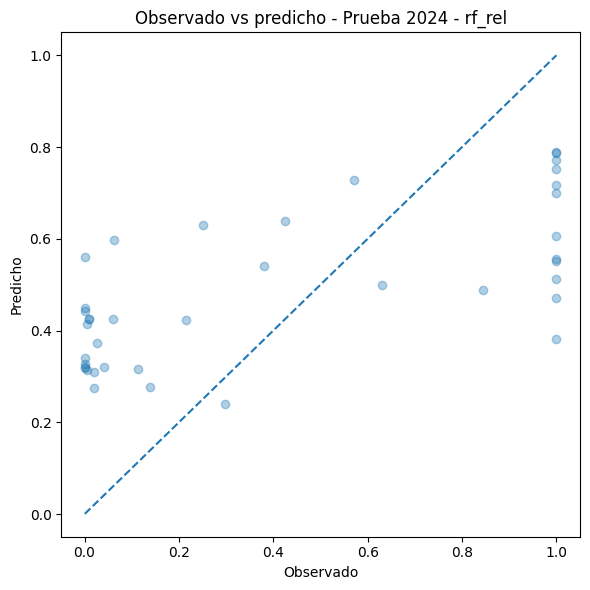


Proceso finalizado: salidas_comparacion_severidad_relativa


In [46]:
# =========================================================
# CONFIGURACION
# =========================================================
RUTA_BASE = "../Data_preparada/Random-forest_LSTMdata/base_severidad.csv"
CARPETA_SALIDA = "salidas_comparacion_severidad_relativa"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

OBJETIVO = "tasa_afectacion_agricola"

# =========================================================
# CARGA Y FILTROS
# =========================================================
df = pd.read_csv(RUTA_BASE)

df["anio"] = pd.to_numeric(df["anio"], errors="coerce")
df["mes"] = pd.to_numeric(df["mes"], errors="coerce")

df = df[
    (df["indicador_eva_observada_fuente"] == 1) &
    (df["area_cosechada_total_ha"] > 0) &
    (df[OBJETIVO].notna()) &
    (df[OBJETIVO] > 0) &
    (df[OBJETIVO] <= 1)
].copy()

print("Filas totales severidad relativa:", len(df))
print("Años:", sorted(df["anio"].dropna().unique()))

# Cap ligero para estabilizar extremos
p99 = df[OBJETIVO].quantile(0.99)
df["tasa_afectacion_agricola_cap"] = np.minimum(df[OBJETIVO], p99)

# =========================================================
# VARIABLES
# =========================================================
columnas_excluir = [
    "codigo_municipio",
    "nombre_municipio",
    "periodo",

    # targets / fuga
    "hubo_inundacion_mes",
    "hubo_inundacion_agricola_mes",
    "numero_eventos_inundacion_mes",
    "numero_eventos_agricolas_mes",
    "hectareas_afectadas_suma_mes",
    "hectareas_afectadas_max_mes",
    "personas_afectadas_suma_mes",
    "familias_afectadas_suma_mes",
    "danio_vivienda_suma_mes",
    "danio_infraestructura_suma_mes",
    "apoyo_fngrd_suma_mes",
    "numero_eventos_con_hectareas_mes",
    "numero_eventos_sin_divipola_mes",
    "indicador_reporte_hectareas_mes",
    "tasa_afectacion_agricola",
    "tasa_afectacion_agricola_cap",
]

columnas_modelo = [c for c in df.columns if c not in columnas_excluir]
print("Variables del modelo:", len(columnas_modelo))

X = df[columnas_modelo].copy()
y = df["tasa_afectacion_agricola_cap"].copy()

# =========================================================
# SPLIT TEMPORAL
# =========================================================
idx_train = df["anio"] <= 2021
idx_val = (df["anio"] >= 2022) & (df["anio"] <= 2023)
idx_test = df["anio"] == 2024

X_train, y_train = X.loc[idx_train], y.loc[idx_train]
X_val, y_val = X.loc[idx_val], y.loc[idx_val]
X_test, y_test = X.loc[idx_test], y.loc[idx_test]

meta_val = df.loc[idx_val, ["codigo_municipio", "anio", "mes"]].copy()
meta_test = df.loc[idx_test, ["codigo_municipio", "anio", "mes"]].copy()

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# =========================================================
# FUNCIONES
# =========================================================
def metricas_regresion(y_real, y_pred):
    y_pred = np.clip(y_pred, 0, p99)

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    try:
        spear = spearmanr(y_real, y_pred).correlation
    except Exception:
        spear = np.nan

    return {
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
        "spearman": None if pd.isna(spear) else float(spear)
    }

def graficar_obs_pred(y_real, y_pred, titulo, ruta):
    y_pred = np.clip(y_pred, 0, p99)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_real, y_pred, alpha=0.35)
    mn = min(np.min(y_real), np.min(y_pred))
    mx = max(np.max(y_real), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Observado")
    plt.ylabel("Predicho")
    plt.title(titulo)
    plt.tight_layout()
    plt.savefig(ruta, dpi=200)
    plt.show()

def a_float_dict(d):
    out = {}
    for k, v in d.items():
        if v is None:
            out[k] = None
        else:
            out[k] = float(v)
    return out

# =========================================================
# MODELOS
# =========================================================
modelos = {
    "rf_rel": Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("modelo", RandomForestRegressor(
            n_estimators=500,
            max_depth=12,
            min_samples_leaf=10,
            min_samples_split=20,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "extra_trees_rel": Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("modelo", ExtraTreesRegressor(
            n_estimators=500,
            max_depth=12,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "gbr_rel": Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("modelo", GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            min_samples_leaf=5,
            random_state=42
        ))
    ]),

    "hist_gbr_rel": Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("modelo", HistGradientBoostingRegressor(
            learning_rate=0.03,
            max_depth=6,
            max_iter=300,
            min_samples_leaf=10,
            l2_regularization=1e-4,
            random_state=42
        ))
    ]),

    "tweedie_rel": Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("modelo", TweedieRegressor(
            power=1.5,
            alpha=0.5,
            link="log",
            max_iter=1000
        ))
    ]),
}

# =========================================================
# ENTRENAMIENTO Y EVALUACION
# =========================================================
resultados = []
preds_val = {}
preds_test = {}
objetos_modelo = {}

for nombre, modelo in modelos.items():
    print(f"\nEvaluando modelo: {nombre}")

    modelo.fit(X_train, y_train)

    pred_val = np.clip(modelo.predict(X_val), 0, p99)
    pred_test = np.clip(modelo.predict(X_test), 0, p99)

    met_val = metricas_regresion(y_val, pred_val)
    met_test = metricas_regresion(y_test, pred_test)

    print("Validación:", met_val)
    print("Prueba:", met_test)

    resultados.append({
        "modelo": nombre,
        "val_rmse": met_val["rmse"],
        "val_mae": met_val["mae"],
        "val_r2": met_val["r2"],
        "val_spearman": met_val["spearman"],
        "test_rmse": met_test["rmse"],
        "test_mae": met_test["mae"],
        "test_r2": met_test["r2"],
        "test_spearman": met_test["spearman"],
    })

    preds_val[nombre] = pred_val
    preds_test[nombre] = pred_test
    objetos_modelo[nombre] = modelo

df_resultados = pd.DataFrame(resultados).sort_values(["val_rmse", "test_rmse"])
df_resultados.to_csv(
    os.path.join(CARPETA_SALIDA, "comparacion_modelos_severidad_relativa.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("\n=== Comparación final ===")
print(df_resultados)

# =========================================================
# SELECCIONAR MEJOR MODELO
# Criterio principal: menor RMSE de validación
# =========================================================
mejor_nombre = df_resultados.iloc[0]["modelo"]
mejor_modelo = objetos_modelo[mejor_nombre]

print("\n=== Mejor modelo ===")
print(mejor_nombre)

# =========================================================
# IMPORTANCIA DE VARIABLES
# Solo para modelos de árboles con feature_importances_
# =========================================================
modelo_interno = mejor_modelo.named_steps["modelo"]

if hasattr(modelo_interno, "feature_importances_"):
    importancias = pd.DataFrame({
        "variable": columnas_modelo,
        "importancia": modelo_interno.feature_importances_
    }).sort_values("importancia", ascending=False)

    print("\n=== TOP 20 VARIABLES ===")
    print(importancias.head(20))

    importancias.to_csv(
        os.path.join(CARPETA_SALIDA, f"importancia_variables_{mejor_nombre}.csv"),
        index=False,
        encoding="utf-8-sig"
    )

    top20 = importancias.head(20).sort_values("importancia", ascending=True)
    plt.figure(figsize=(10, 8))
    plt.barh(top20["variable"], top20["importancia"])
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.title(f"Top 20 variables - {mejor_nombre}")
    plt.tight_layout()
    plt.savefig(os.path.join(CARPETA_SALIDA, f"top20_importancia_{mejor_nombre}.png"), dpi=200)
    plt.show()

# =========================================================
# GRAFICOS OBS VS PRED DEL MEJOR
# =========================================================
graficar_obs_pred(
    y_val.values,
    preds_val[mejor_nombre],
    f"Observado vs predicho - Validación - {mejor_nombre}",
    os.path.join(CARPETA_SALIDA, f"obs_vs_pred_validacion_{mejor_nombre}.png")
)

graficar_obs_pred(
    y_test.values,
    preds_test[mejor_nombre],
    f"Observado vs predicho - Prueba 2024 - {mejor_nombre}",
    os.path.join(CARPETA_SALIDA, f"obs_vs_pred_prueba_{mejor_nombre}.png")
)

# =========================================================
# GUARDAR PREDICCIONES
# =========================================================
pred_val_df = meta_val.copy()
pred_val_df["observado_tasa"] = y_val.values
for nombre, pred in preds_val.items():
    pred_val_df[f"pred_{nombre}"] = pred

pred_test_df = meta_test.copy()
pred_test_df["observado_tasa"] = y_test.values
for nombre, pred in preds_test.items():
    pred_test_df[f"pred_{nombre}"] = pred

pred_val_df.to_csv(
    os.path.join(CARPETA_SALIDA, "predicciones_validacion_todos_modelos.csv"),
    index=False,
    encoding="utf-8-sig"
)

pred_test_df.to_csv(
    os.path.join(CARPETA_SALIDA, "predicciones_prueba_todos_modelos.csv"),
    index=False,
    encoding="utf-8-sig"
)

# =========================================================
# GUARDAR MEJOR MODELO
# =========================================================
joblib.dump(
    mejor_modelo,
    os.path.join(CARPETA_SALIDA, f"mejor_modelo_{mejor_nombre}.joblib")
)

metadatos = {
    "objetivo": OBJETIVO,
    "objetivo_modelado": "tasa_afectacion_agricola_cap",
    "p99_cap": float(p99),
    "mejor_modelo": mejor_nombre,
    "tabla_resultados": df_resultados.to_dict(orient="records")
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_comparacion_severidad_relativa.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

### Base con EVA

#### Modelo 5

Filas totales severidad relativa: 194
Años: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Variables del modelo: 44
Train: (82, 44)
Val: (73, 44)
Test: (39, 44)

=== Tuning RF ===

=== Tuning GBR ===

=== Tuning Tweedie ===

=== Mejores por familia ===
        modelo                                        config_json  val_rmse  \
0       rf_rel  {"familia": "rf_rel", "n_estimators": 500, "ma...  0.384580   
1      gbr_rel  {"familia": "gbr_rel", "n_estimators": 200, "l...  0.395508   
2  tweedie_rel  {"familia": "tweedie_rel", "power": 1.9, "alph...  0.398105   

    val_mae    val_r2  val_spearman  test_rmse  test_mae   test_r2  \
0  0.342017  0.128785      0.425263   0.351785  0.327686  0.341057   
1  0.339743  0.078572      0.369903   0.344011  0.309411  0.369860   
2  0.349561  0.066433      0.339739   0.348064  0.301334  0.354923   

   test_spearman  
0       0.602920  
1       0.631988  
2       0.555467  

=== Mejor modelo globa

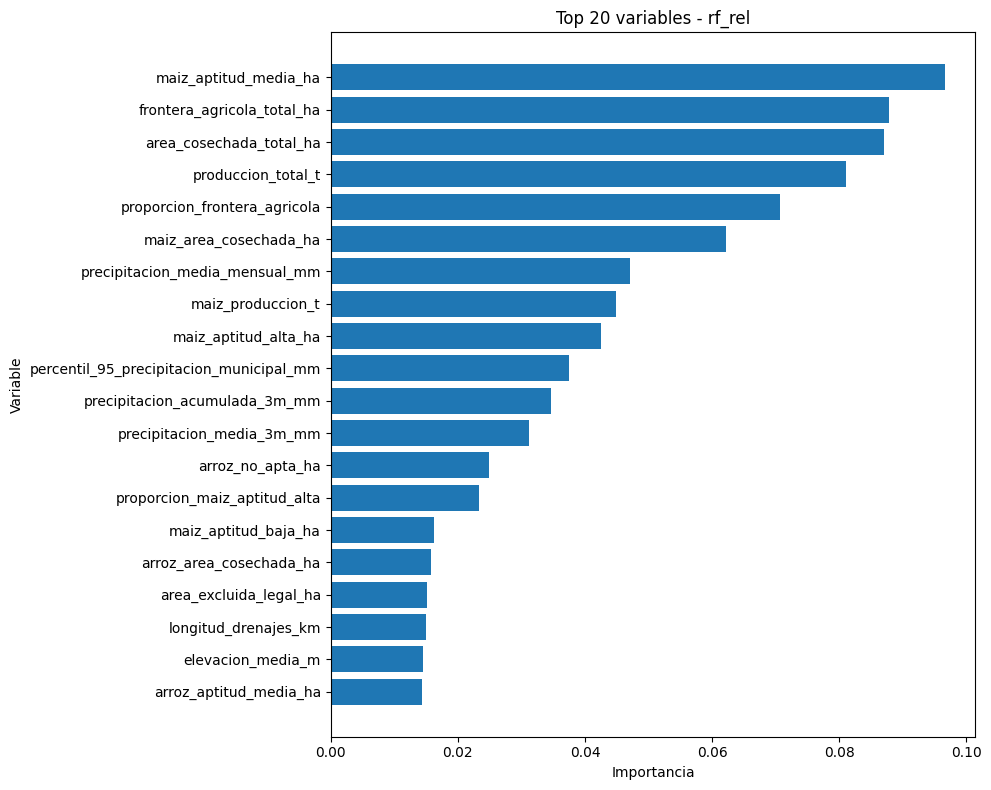

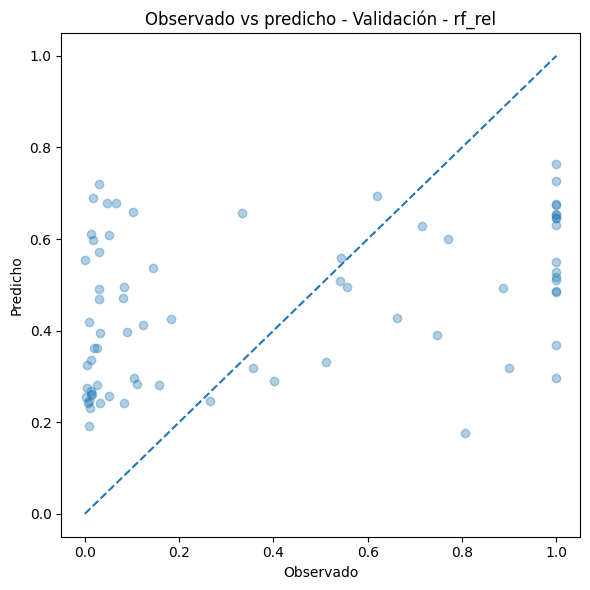

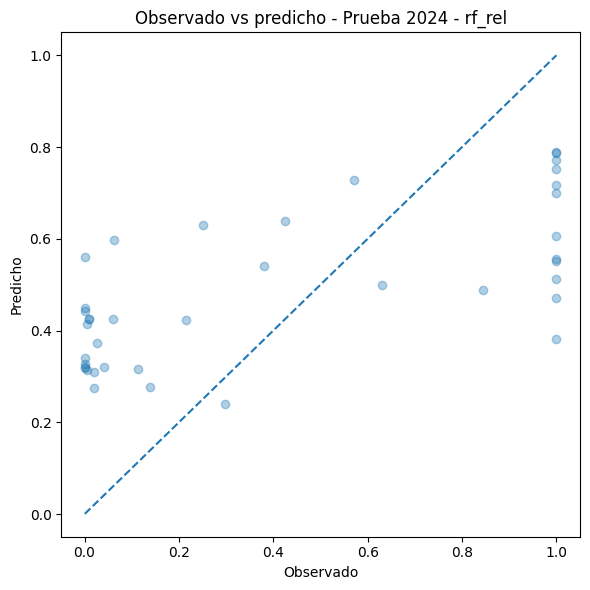


Proceso finalizado: salidas_tuning_severidad_relativa_ronda2


In [49]:
import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from scipy.stats import spearmanr

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import TweedieRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# =========================================================
# CONFIGURACION
# =========================================================
RUTA_BASE = "../Data_preparada/Random-forest_LSTMdata/panel_modelo_2019_2024_con_eva.csv"
CARPETA_SALIDA = "salidas_tuning_severidad_relativa_ronda2"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

OBJETIVO = "tasa_afectacion_agricola"

# =========================================================
# CARGA Y FILTROS
# =========================================================
df = pd.read_csv(RUTA_BASE)

df["anio"] = pd.to_numeric(df["anio"], errors="coerce")
df["mes"] = pd.to_numeric(df["mes"], errors="coerce")

df = df[
    (df["indicador_eva_observada_fuente"] == 1) &
    (df["area_cosechada_total_ha"] > 0) &
    (df[OBJETIVO].notna()) &
    (df[OBJETIVO] > 0) &
    (df[OBJETIVO] <= 1)
].copy()

print("Filas totales severidad relativa:", len(df))
print("Años:", sorted(df["anio"].dropna().unique()))

# Cap ligero
p99 = df[OBJETIVO].quantile(0.99)
df["tasa_afectacion_agricola_cap"] = np.minimum(df[OBJETIVO], p99)

# =========================================================
# VARIABLES
# =========================================================
columnas_excluir = [
    "codigo_municipio",
    "nombre_municipio",
    "periodo",

    # fuga / targets
    "hubo_inundacion_mes",
    "hubo_inundacion_agricola_mes",
    "numero_eventos_inundacion_mes",
    "numero_eventos_agricolas_mes",
    "hectareas_afectadas_suma_mes",
    "hectareas_afectadas_max_mes",
    "personas_afectadas_suma_mes",
    "familias_afectadas_suma_mes",
    "danio_vivienda_suma_mes",
    "danio_infraestructura_suma_mes",
    "apoyo_fngrd_suma_mes",
    "numero_eventos_con_hectareas_mes",
    "numero_eventos_sin_divipola_mes",
    "indicador_reporte_hectareas_mes",
    "tasa_afectacion_agricola",
    "tasa_afectacion_agricola_cap",
]

columnas_modelo = [c for c in df.columns if c not in columnas_excluir]

X = df[columnas_modelo].copy()
y = df["tasa_afectacion_agricola_cap"].copy()

print("Variables del modelo:", len(columnas_modelo))

# =========================================================
# SPLIT TEMPORAL
# =========================================================
idx_train = df["anio"] <= 2021
idx_val = (df["anio"] >= 2022) & (df["anio"] <= 2023)
idx_test = df["anio"] == 2024

X_train, y_train = X.loc[idx_train], y.loc[idx_train]
X_val, y_val = X.loc[idx_val], y.loc[idx_val]
X_test, y_test = X.loc[idx_test], y.loc[idx_test]

meta_val = df.loc[idx_val, ["codigo_municipio", "anio", "mes"]].copy()
meta_test = df.loc[idx_test, ["codigo_municipio", "anio", "mes"]].copy()

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# =========================================================
# FUNCIONES
# =========================================================
def metricas_regresion(y_real, y_pred):
    y_pred = np.clip(y_pred, 0, p99)

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    try:
        spear = spearmanr(y_real, y_pred).correlation
    except Exception:
        spear = np.nan

    return {
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
        "spearman": None if pd.isna(spear) else float(spear)
    }

def mejor_fila(df_res):
    # menor RMSE y luego mayor Spearman
    df_tmp = df_res.copy()
    df_tmp["spearman_aux"] = df_tmp["val_spearman"].fillna(-999)
    df_tmp = df_tmp.sort_values(["val_rmse", "spearman_aux"], ascending=[True, False])
    return df_tmp.iloc[0]

def graficar_obs_pred(y_real, y_pred, titulo, ruta):
    y_pred = np.clip(y_pred, 0, p99)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_real, y_pred, alpha=0.35)
    mn = min(np.min(y_real), np.min(y_pred))
    mx = max(np.max(y_real), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Observado")
    plt.ylabel("Predicho")
    plt.title(titulo)
    plt.tight_layout()
    plt.savefig(ruta, dpi=200)
    plt.show()

# =========================================================
# CONSTRUCTORES DE MODELOS
# =========================================================
def construir_rf(config):
    return Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("modelo", RandomForestRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            min_samples_split=config["min_samples_split"],
            max_features=config["max_features"],
            random_state=42,
            n_jobs=-1
        ))
    ])

def construir_gbr(config):
    return Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("modelo", GradientBoostingRegressor(
            n_estimators=config["n_estimators"],
            learning_rate=config["learning_rate"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            subsample=config["subsample"],
            random_state=42
        ))
    ])

def construir_tweedie(config):
    return Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("modelo", TweedieRegressor(
            power=config["power"],
            alpha=config["alpha"],
            link="log",
            max_iter=2000
        ))
    ])

# =========================================================
# GRILLAS
# =========================================================
grid_rf = [
    {
        "familia": "rf_rel",
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "min_samples_split": min_samples_split,
        "max_features": "sqrt",
    }
    for n_estimators, max_depth, min_samples_leaf, min_samples_split in product(
        [300, 500],
        [10, 12, 16],
        [5, 10],
        [10, 20],
    )
]

grid_gbr = [
    {
        "familia": "gbr_rel",
        "n_estimators": n_estimators,
        "learning_rate": learning_rate,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "subsample": subsample,
    }
    for n_estimators, learning_rate, max_depth, min_samples_leaf, subsample in product(
        [200, 300, 500],
        [0.01, 0.03, 0.05],
        [2, 3],
        [3, 5, 10],
        [0.8, 1.0],
    )
]

# grilla reducida de Tweedie para no exagerar
grid_tweedie = [
    {
        "familia": "tweedie_rel",
        "power": power,
        "alpha": alpha,
    }
    for power, alpha in product(
        [1.3, 1.5, 1.7, 1.9],
        [0.1, 0.5, 1.0, 2.0],
    )
]

# =========================================================
# EVALUACION DE GRILLAS
# =========================================================
resultados = []
mejores_modelos = {}

def evaluar_config(nombre_modelo, config, constructor):
    modelo = constructor(config)
    modelo.fit(X_train, y_train)

    pred_val = np.clip(modelo.predict(X_val), 0, p99)
    pred_test = np.clip(modelo.predict(X_test), 0, p99)

    met_val = metricas_regresion(y_val, pred_val)
    met_test = metricas_regresion(y_test, pred_test)

    fila = {
        "modelo": nombre_modelo,
        "config_json": json.dumps(config, ensure_ascii=False),
        "val_rmse": met_val["rmse"],
        "val_mae": met_val["mae"],
        "val_r2": met_val["r2"],
        "val_spearman": met_val["spearman"],
        "test_rmse": met_test["rmse"],
        "test_mae": met_test["mae"],
        "test_r2": met_test["r2"],
        "test_spearman": met_test["spearman"],
    }
    return fila, modelo, pred_val, pred_test

# RF
print("\n=== Tuning RF ===")
rf_rows = []
rf_best_row = None
rf_best_model = None
rf_best_val_pred = None
rf_best_test_pred = None

for i, config in enumerate(grid_rf, start=1):
    fila, modelo, pred_val, pred_test = evaluar_config("rf_rel", config, construir_rf)
    rf_rows.append(fila)

    if rf_best_row is None:
        rf_best_row = fila
        rf_best_model = modelo
        rf_best_val_pred = pred_val
        rf_best_test_pred = pred_test
    else:
        actual = pd.DataFrame([rf_best_row, fila])
        best = mejor_fila(actual)
        if best["config_json"] == fila["config_json"]:
            rf_best_row = fila
            rf_best_model = modelo
            rf_best_val_pred = pred_val
            rf_best_test_pred = pred_test

rf_df = pd.DataFrame(rf_rows)
resultados.append(rf_df)

# GBR
print("\n=== Tuning GBR ===")
gbr_rows = []
gbr_best_row = None
gbr_best_model = None
gbr_best_val_pred = None
gbr_best_test_pred = None

for i, config in enumerate(grid_gbr, start=1):
    fila, modelo, pred_val, pred_test = evaluar_config("gbr_rel", config, construir_gbr)
    gbr_rows.append(fila)

    if gbr_best_row is None:
        gbr_best_row = fila
        gbr_best_model = modelo
        gbr_best_val_pred = pred_val
        gbr_best_test_pred = pred_test
    else:
        actual = pd.DataFrame([gbr_best_row, fila])
        best = mejor_fila(actual)
        if best["config_json"] == fila["config_json"]:
            gbr_best_row = fila
            gbr_best_model = modelo
            gbr_best_val_pred = pred_val
            gbr_best_test_pred = pred_test

gbr_df = pd.DataFrame(gbr_rows)
resultados.append(gbr_df)

# Tweedie
print("\n=== Tuning Tweedie ===")
twd_rows = []
twd_best_row = None
twd_best_model = None
twd_best_val_pred = None
twd_best_test_pred = None

for i, config in enumerate(grid_tweedie, start=1):
    fila, modelo, pred_val, pred_test = evaluar_config("tweedie_rel", config, construir_tweedie)
    twd_rows.append(fila)

    if twd_best_row is None:
        twd_best_row = fila
        twd_best_model = modelo
        twd_best_val_pred = pred_val
        twd_best_test_pred = pred_test
    else:
        actual = pd.DataFrame([twd_best_row, fila])
        best = mejor_fila(actual)
        if best["config_json"] == fila["config_json"]:
            twd_best_row = fila
            twd_best_model = modelo
            twd_best_val_pred = pred_val
            twd_best_test_pred = pred_test

twd_df = pd.DataFrame(twd_rows)
resultados.append(twd_df)

# =========================================================
# RESUMEN DE MEJORES POR FAMILIA
# =========================================================
mejores_familia = pd.DataFrame([
    rf_best_row,
    gbr_best_row,
    twd_best_row,
])

mejores_familia["val_spearman_aux"] = mejores_familia["val_spearman"].fillna(-999)
mejores_familia = mejores_familia.sort_values(["val_rmse", "val_spearman_aux"], ascending=[True, False]).drop(columns=["val_spearman_aux"])

print("\n=== Mejores por familia ===")
print(mejores_familia)

mejores_familia.to_csv(
    os.path.join(CARPETA_SALIDA, "mejores_por_familia_severidad_relativa.csv"),
    index=False,
    encoding="utf-8-sig"
)

# guardar tablas completas
rf_df.sort_values(["val_rmse", "val_spearman"], ascending=[True, False]).to_csv(
    os.path.join(CARPETA_SALIDA, "tuning_rf_rel.csv"),
    index=False,
    encoding="utf-8-sig"
)

gbr_df.sort_values(["val_rmse", "val_spearman"], ascending=[True, False]).to_csv(
    os.path.join(CARPETA_SALIDA, "tuning_gbr_rel.csv"),
    index=False,
    encoding="utf-8-sig"
)

twd_df.sort_values(["val_rmse", "val_spearman"], ascending=[True, False]).to_csv(
    os.path.join(CARPETA_SALIDA, "tuning_tweedie_rel.csv"),
    index=False,
    encoding="utf-8-sig"
)

# =========================================================
# SELECCION GLOBAL POR VALIDACION
# =========================================================
mejor_global = mejores_familia.iloc[0]
mejor_nombre = mejor_global["modelo"]
mejor_config = json.loads(mejor_global["config_json"])

print("\n=== Mejor modelo global por validación ===")
print(mejor_nombre)
print(mejor_config)

if mejor_nombre == "rf_rel":
    mejor_modelo = rf_best_model
    pred_val = rf_best_val_pred
    pred_test = rf_best_test_pred
elif mejor_nombre == "gbr_rel":
    mejor_modelo = gbr_best_model
    pred_val = gbr_best_val_pred
    pred_test = gbr_best_test_pred
else:
    mejor_modelo = twd_best_model
    pred_val = twd_best_val_pred
    pred_test = twd_best_test_pred

# =========================================================
# IMPORTANCIAS SI APLICA
# =========================================================
modelo_interno = mejor_modelo.named_steps["modelo"]
if hasattr(modelo_interno, "feature_importances_"):
    importancias = pd.DataFrame({
        "variable": columnas_modelo,
        "importancia": modelo_interno.feature_importances_
    }).sort_values("importancia", ascending=False)

    print("\n=== TOP 20 VARIABLES DEL MEJOR GLOBAL ===")
    print(importancias.head(20))

    importancias.to_csv(
        os.path.join(CARPETA_SALIDA, f"importancia_variables_{mejor_nombre}.csv"),
        index=False,
        encoding="utf-8-sig"
    )

    top20 = importancias.head(20).sort_values("importancia", ascending=True)
    plt.figure(figsize=(10, 8))
    plt.barh(top20["variable"], top20["importancia"])
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.title(f"Top 20 variables - {mejor_nombre}")
    plt.tight_layout()
    plt.savefig(os.path.join(CARPETA_SALIDA, f"top20_importancia_{mejor_nombre}.png"), dpi=200)
    plt.show()

# =========================================================
# GRAFICOS DEL MEJOR GLOBAL
# =========================================================
graficar_obs_pred(
    y_val.values,
    pred_val,
    f"Observado vs predicho - Validación - {mejor_nombre}",
    os.path.join(CARPETA_SALIDA, f"obs_vs_pred_validacion_{mejor_nombre}.png")
)

graficar_obs_pred(
    y_test.values,
    pred_test,
    f"Observado vs predicho - Prueba 2024 - {mejor_nombre}",
    os.path.join(CARPETA_SALIDA, f"obs_vs_pred_prueba_{mejor_nombre}.png")
)

# =========================================================
# GUARDAR PREDICCIONES
# =========================================================
pred_val_df = meta_val.copy()
pred_val_df["observado_tasa"] = y_val.values
pred_val_df["pred_rf_rel"] = rf_best_val_pred
pred_val_df["pred_gbr_rel"] = gbr_best_val_pred
pred_val_df["pred_tweedie_rel"] = twd_best_val_pred

pred_test_df = meta_test.copy()
pred_test_df["observado_tasa"] = y_test.values
pred_test_df["pred_rf_rel"] = rf_best_test_pred
pred_test_df["pred_gbr_rel"] = gbr_best_test_pred
pred_test_df["pred_tweedie_rel"] = twd_best_test_pred

pred_val_df.to_csv(
    os.path.join(CARPETA_SALIDA, "predicciones_validacion_mejores_familias.csv"),
    index=False,
    encoding="utf-8-sig"
)

pred_test_df.to_csv(
    os.path.join(CARPETA_SALIDA, "predicciones_prueba_mejores_familias.csv"),
    index=False,
    encoding="utf-8-sig"
)

# =========================================================
# GUARDAR MODELO Y METADATOS
# =========================================================
joblib.dump(
    mejor_modelo,
    os.path.join(CARPETA_SALIDA, f"mejor_modelo_{mejor_nombre}.joblib")
)

metadatos = {
    "objetivo": OBJETIVO,
    "objetivo_modelado": "tasa_afectacion_agricola_cap",
    "p99_cap": float(p99),
    "mejor_modelo_global_validacion": mejor_nombre,
    "mejor_config_global_validacion": mejor_config,
    "mejores_por_familia": mejores_familia.to_dict(orient="records"),
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_tuning_severidad_relativa_ronda2.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

### Solo RF con EVA para evaluar severidad relativa

#### Modelo 6

In [50]:
# =========================================================
# 1. CONFIGURACION
# =========================================================
RUTA_BASE = "../Data_preparada/Random-forest_LSTMdata/panel_modelo_2019_2024_con_eva.csv"
CARPETA_SALIDA = "rf_severidad_relativa_neto"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

OBJETIVO = "tasa_afectacion_agricola"

GRID_RF = {
    "n_estimators": [300, 500, 800],
    "max_depth": [8, 10, 12, 16, None],
    "min_samples_leaf": [3, 5, 10],
    "min_samples_split": [5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5]
}

# =========================================================
# 2. CARGA Y FILTROS
# =========================================================
df = pd.read_csv(RUTA_BASE)

df["anio"] = pd.to_numeric(df["anio"], errors="coerce")
df["mes"] = pd.to_numeric(df["mes"], errors="coerce")

# Filtros para severidad relativa
df = df[
    (df["indicador_eva_observada_fuente"] == 1) &
    (df["area_cosechada_total_ha"] > 0) &
    (df[OBJETIVO].notna()) &
    (df[OBJETIVO] > 0) &
    (df[OBJETIVO] <= 1)
].copy()

print("Filas totales:", len(df))
print("Años:", sorted(df["anio"].dropna().unique()))

# Cap ligero para estabilizar extremos
p99 = df[OBJETIVO].quantile(0.99)
df["target_modelo"] = np.minimum(df[OBJETIVO], p99)

# =========================================================
# 3. VARIABLES
# =========================================================
columnas_excluir = [
    "codigo_municipio",
    "nombre_municipio",
    "periodo",

    # targets / fuga
    "hubo_inundacion_mes",
    "hubo_inundacion_agricola_mes",
    "numero_eventos_inundacion_mes",
    "numero_eventos_agricolas_mes",
    "hectareas_afectadas_suma_mes",
    "hectareas_afectadas_max_mes",
    "personas_afectadas_suma_mes",
    "familias_afectadas_suma_mes",
    "danio_vivienda_suma_mes",
    "danio_infraestructura_suma_mes",
    "apoyo_fngrd_suma_mes",
    "numero_eventos_con_hectareas_mes",
    "numero_eventos_sin_divipola_mes",
    "indicador_reporte_hectareas_mes",

    # target
    "tasa_afectacion_agricola",
    "target_modelo",
]

columnas_modelo = [c for c in df.columns if c not in columnas_excluir]

X = df[columnas_modelo].copy()
y = df["target_modelo"].copy()

print("Variables del modelo:", len(columnas_modelo))

# =========================================================
# 4. SPLIT TEMPORAL
# =========================================================
idx_train = df["anio"] <= 2021
idx_val = (df["anio"] >= 2022) & (df["anio"] <= 2023)
idx_test = df["anio"] == 2024

X_train, y_train = X.loc[idx_train], y.loc[idx_train]
X_val, y_val = X.loc[idx_val], y.loc[idx_val]
X_test, y_test = X.loc[idx_test], y.loc[idx_test]

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# =========================================================
# 5. FUNCIONES
# =========================================================
def metricas_regresion(y_real, y_pred):
    y_pred = np.clip(y_pred, 0, p99)

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    try:
        spear = spearmanr(y_real, y_pred).correlation
    except Exception:
        spear = np.nan

    return {
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
        "spearman": None if pd.isna(spear) else float(spear)
    }

def construir_modelo(config):
    modelo = Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("rf", RandomForestRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            min_samples_split=config["min_samples_split"],
            max_features=config["max_features"],
            random_state=42,
            n_jobs=-1
        ))
    ])
    return modelo

def graficar_obs_pred(y_real, y_pred, titulo, ruta):
    y_pred = np.clip(y_pred, 0, p99)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_real, y_pred, alpha=0.35)
    mn = min(np.min(y_real), np.min(y_pred))
    mx = max(np.max(y_real), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Observado")
    plt.ylabel("Predicho")
    plt.title(titulo)
    plt.tight_layout()
    plt.savefig(ruta, dpi=200)
    plt.close()

# =========================================================
# 6. TUNING RANDOM FOREST
# =========================================================
combinaciones = list(product(
    GRID_RF["n_estimators"],
    GRID_RF["max_depth"],
    GRID_RF["min_samples_leaf"],
    GRID_RF["min_samples_split"],
    GRID_RF["max_features"]
))

resultados = []
mejor_modelo = None
mejor_config = None
mejor_pred_val = None
mejor_pred_test = None
mejor_score = np.inf

for i, (n_estimators, max_depth, min_samples_leaf, min_samples_split, max_features) in enumerate(combinaciones, start=1):
    config = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "min_samples_split": min_samples_split,
        "max_features": max_features
    }

    print(f"\nModelo {i}/{len(combinaciones)} -> {config}")

    modelo = construir_modelo(config)
    modelo.fit(X_train, y_train)

    pred_val = np.clip(modelo.predict(X_val), 0, p99)
    pred_test = np.clip(modelo.predict(X_test), 0, p99)

    met_val = metricas_regresion(y_val, pred_val)
    met_test = metricas_regresion(y_test, pred_test)

    resultados.append({
        **config,
        "val_rmse": met_val["rmse"],
        "val_mae": met_val["mae"],
        "val_r2": met_val["r2"],
        "val_spearman": met_val["spearman"],
        "test_rmse": met_test["rmse"],
        "test_mae": met_test["mae"],
        "test_r2": met_test["r2"],
        "test_spearman": met_test["spearman"],
    })

    print("Validación:", met_val)
    print("Prueba:", met_test)

    # criterio principal: menor RMSE de validación
    # desempate: mayor Spearman de validación
    score_actual = met_val["rmse"]
    if mejor_modelo is None:
        mejor_modelo = modelo
        mejor_config = config
        mejor_pred_val = pred_val
        mejor_pred_test = pred_test
        mejor_score = score_actual
        mejor_spearman = met_val["spearman"] if met_val["spearman"] is not None else -999
    else:
        spearman_actual = met_val["spearman"] if met_val["spearman"] is not None else -999
        if (score_actual < mejor_score) or (np.isclose(score_actual, mejor_score) and spearman_actual > mejor_spearman):
            mejor_modelo = modelo
            mejor_config = config
            mejor_pred_val = pred_val
            mejor_pred_test = pred_test
            mejor_score = score_actual
            mejor_spearman = spearman_actual

# =========================================================
# 7. RESULTADOS FINALES
# =========================================================
df_resultados = pd.DataFrame(resultados).sort_values(
    ["val_rmse", "val_spearman"],
    ascending=[True, False]
)

df_resultados.to_csv(
    os.path.join(CARPETA_SALIDA, "resultados_tuning_rf.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("\n=== MEJOR CONFIGURACION ===")
print(mejor_config)

met_val_final = metricas_regresion(y_val, mejor_pred_val)
met_test_final = metricas_regresion(y_test, mejor_pred_test)

print("\n=== VALIDACION FINAL ===")
print(met_val_final)

print("\n=== PRUEBA FINAL ===")
print(met_test_final)

# =========================================================
# 8. IMPORTANCIA DE VARIABLES
# =========================================================
rf = mejor_modelo.named_steps["rf"]
importancias = pd.DataFrame({
    "variable": columnas_modelo,
    "importancia": rf.feature_importances_
}).sort_values("importancia", ascending=False)

print("\n=== TOP 20 VARIABLES ===")
print(importancias.head(20))

importancias.to_csv(
    os.path.join(CARPETA_SALIDA, "importancia_variables_rf.csv"),
    index=False,
    encoding="utf-8-sig"
)

top20 = importancias.head(20).sort_values("importancia", ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(top20["variable"], top20["importancia"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 20 variables - Random Forest severidad relativa")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "top20_importancia_rf.png"), dpi=200)
plt.close()

# =========================================================
# 9. GRAFICOS OBS VS PRED
# =========================================================
graficar_obs_pred(
    y_val.values,
    mejor_pred_val,
    "Observado vs predicho - Validación",
    os.path.join(CARPETA_SALIDA, "obs_vs_pred_validacion.png")
)

graficar_obs_pred(
    y_test.values,
    mejor_pred_test,
    "Observado vs predicho - Prueba 2024",
    os.path.join(CARPETA_SALIDA, "obs_vs_pred_prueba.png")
)

# =========================================================
# 10. GUARDAR MODELO
# =========================================================
joblib.dump(
    mejor_modelo,
    os.path.join(CARPETA_SALIDA, "mejor_modelo_rf.joblib")
)

metadatos = {
    "objetivo": OBJETIVO,
    "objetivo_modelado": "target_modelo",
    "p99_cap": float(p99),
    "mejor_configuracion": mejor_config,
    "metricas_validacion_final": met_val_final,
    "metricas_prueba_final": met_test_final,
    "columnas_modelo": columnas_modelo
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_rf.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

Filas totales: 194
Años: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Variables del modelo: 44
Train: (82, 44)
Val: (73, 44)
Test: (39, 44)

Modelo 1/405 -> {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 5, 'max_features': 'sqrt'}
Validación: {'rmse': 0.3880107212796066, 'mae': 0.3322657021505544, 'r2': 0.11317314669394896, 'spearman': 0.437651914330883}
Prueba: {'rmse': 0.31680953938705997, 'mae': 0.2809379967013737, 'r2': 0.46557241052107523, 'spearman': 0.6791325020972125}

Modelo 2/405 -> {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 5, 'max_features': 'log2'}
Validación: {'rmse': 0.3908149885731855, 'mae': 0.3380085931420569, 'r2': 0.10030810880130048, 'spearman': 0.4351369411081664}
Prueba: {'rmse': 0.3243665536399599, 'mae': 0.28895449493728453, 'r2': 0.43977239707933513, 'spearman': 0.6464700496370017}

Modelo 3/405 -> {'n_estimators': 300, 'max_depth': 8, 

#### Modelo 7

In [51]:
# =========================================================
# 1. CONFIGURACION
# =========================================================
RUTA_BASE = "../Data_preparada/Random-forest_LSTMdata/panel_modelo_2019_2024_con_eva.csv"
CARPETA_SALIDA = "rf_severidad_relativa_neto"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

OBJETIVO = "tasa_afectacion_agricola"

GRID_RF = {
    "n_estimators": [300, 500, 800],
    "max_depth": [8, 10, 12, 16, 20,24],
    "min_samples_leaf": [3, 5, 10],
    "min_samples_split": [5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5]
}

# =========================================================
# 2. CARGA Y FILTROS
# =========================================================
df = pd.read_csv(RUTA_BASE)

df["anio"] = pd.to_numeric(df["anio"], errors="coerce")
df["mes"] = pd.to_numeric(df["mes"], errors="coerce")

# Filtros para severidad relativa
df = df[
    (df["indicador_eva_observada_fuente"] == 1) &
    (df["area_cosechada_total_ha"] > 0) &
    (df[OBJETIVO].notna()) &
    (df[OBJETIVO] > 0) &
    (df[OBJETIVO] <= 1)
].copy()

print("Filas totales:", len(df))
print("Años:", sorted(df["anio"].dropna().unique()))

# Cap ligero para estabilizar extremos
p99 = df[OBJETIVO].quantile(0.99)
df["target_modelo"] = np.minimum(df[OBJETIVO], p99)

# =========================================================
# 3. VARIABLES
# =========================================================
columnas_excluir = [
    "codigo_municipio",
    "nombre_municipio",
    "periodo",

    # targets / fuga
    "hubo_inundacion_mes",
    "hubo_inundacion_agricola_mes",
    "numero_eventos_inundacion_mes",
    "numero_eventos_agricolas_mes",
    "hectareas_afectadas_suma_mes",
    "hectareas_afectadas_max_mes",
    "personas_afectadas_suma_mes",
    "familias_afectadas_suma_mes",
    "danio_vivienda_suma_mes",
    "danio_infraestructura_suma_mes",
    "apoyo_fngrd_suma_mes",
    "numero_eventos_con_hectareas_mes",
    "numero_eventos_sin_divipola_mes",
    "indicador_reporte_hectareas_mes",

    # target
    "tasa_afectacion_agricola",
    "target_modelo",
]

columnas_modelo = [c for c in df.columns if c not in columnas_excluir]

X = df[columnas_modelo].copy()
y = df["target_modelo"].copy()

print("Variables del modelo:", len(columnas_modelo))

# =========================================================
# 4. SPLIT TEMPORAL
# =========================================================
idx_train = df["anio"] <= 2021
idx_val = (df["anio"] >= 2022) & (df["anio"] <= 2023)
idx_test = df["anio"] == 2024

X_train, y_train = X.loc[idx_train], y.loc[idx_train]
X_val, y_val = X.loc[idx_val], y.loc[idx_val]
X_test, y_test = X.loc[idx_test], y.loc[idx_test]

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# =========================================================
# 5. FUNCIONES
# =========================================================
def metricas_regresion(y_real, y_pred):
    y_pred = np.clip(y_pred, 0, p99)

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    try:
        spear = spearmanr(y_real, y_pred).correlation
    except Exception:
        spear = np.nan

    return {
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
        "spearman": None if pd.isna(spear) else float(spear)
    }

def construir_modelo(config):
    modelo = Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("rf", RandomForestRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            min_samples_split=config["min_samples_split"],
            max_features=config["max_features"],
            random_state=42,
            n_jobs=-1
        ))
    ])
    return modelo

def graficar_obs_pred(y_real, y_pred, titulo, ruta):
    y_pred = np.clip(y_pred, 0, p99)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_real, y_pred, alpha=0.35)
    mn = min(np.min(y_real), np.min(y_pred))
    mx = max(np.max(y_real), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Observado")
    plt.ylabel("Predicho")
    plt.title(titulo)
    plt.tight_layout()
    plt.savefig(ruta, dpi=200)
    plt.close()

# =========================================================
# 6. TUNING RANDOM FOREST
# =========================================================
combinaciones = list(product(
    GRID_RF["n_estimators"],
    GRID_RF["max_depth"],
    GRID_RF["min_samples_leaf"],
    GRID_RF["min_samples_split"],
    GRID_RF["max_features"]
))

resultados = []
mejor_modelo = None
mejor_config = None
mejor_pred_val = None
mejor_pred_test = None
mejor_score = np.inf

for i, (n_estimators, max_depth, min_samples_leaf, min_samples_split, max_features) in enumerate(combinaciones, start=1):
    config = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "min_samples_split": min_samples_split,
        "max_features": max_features
    }

    print(f"\nModelo {i}/{len(combinaciones)} -> {config}")

    modelo = construir_modelo(config)
    modelo.fit(X_train, y_train)

    pred_val = np.clip(modelo.predict(X_val), 0, p99)
    pred_test = np.clip(modelo.predict(X_test), 0, p99)

    met_val = metricas_regresion(y_val, pred_val)
    met_test = metricas_regresion(y_test, pred_test)

    resultados.append({
        **config,
        "val_rmse": met_val["rmse"],
        "val_mae": met_val["mae"],
        "val_r2": met_val["r2"],
        "val_spearman": met_val["spearman"],
        "test_rmse": met_test["rmse"],
        "test_mae": met_test["mae"],
        "test_r2": met_test["r2"],
        "test_spearman": met_test["spearman"],
    })

    print("Validación:", met_val)
    print("Prueba:", met_test)

    # criterio principal: menor RMSE de validación
    # desempate: mayor Spearman de validación
    score_actual = met_val["rmse"]
    if mejor_modelo is None:
        mejor_modelo = modelo
        mejor_config = config
        mejor_pred_val = pred_val
        mejor_pred_test = pred_test
        mejor_score = score_actual
        mejor_spearman = met_val["spearman"] if met_val["spearman"] is not None else -999
    else:
        spearman_actual = met_val["spearman"] if met_val["spearman"] is not None else -999
        if (score_actual < mejor_score) or (np.isclose(score_actual, mejor_score) and spearman_actual > mejor_spearman):
            mejor_modelo = modelo
            mejor_config = config
            mejor_pred_val = pred_val
            mejor_pred_test = pred_test
            mejor_score = score_actual
            mejor_spearman = spearman_actual

# =========================================================
# 7. RESULTADOS FINALES
# =========================================================
df_resultados = pd.DataFrame(resultados).sort_values(
    ["val_rmse", "val_spearman"],
    ascending=[True, False]
)

df_resultados.to_csv(
    os.path.join(CARPETA_SALIDA, "resultados_tuning_rf.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("\n=== MEJOR CONFIGURACION ===")
print(mejor_config)

met_val_final = metricas_regresion(y_val, mejor_pred_val)
met_test_final = metricas_regresion(y_test, mejor_pred_test)

print("\n=== VALIDACION FINAL ===")
print(met_val_final)

print("\n=== PRUEBA FINAL ===")
print(met_test_final)

# =========================================================
# 8. IMPORTANCIA DE VARIABLES
# =========================================================
rf = mejor_modelo.named_steps["rf"]
importancias = pd.DataFrame({
    "variable": columnas_modelo,
    "importancia": rf.feature_importances_
}).sort_values("importancia", ascending=False)

print("\n=== TOP 20 VARIABLES ===")
print(importancias.head(20))

importancias.to_csv(
    os.path.join(CARPETA_SALIDA, "importancia_variables_rf.csv"),
    index=False,
    encoding="utf-8-sig"
)

top20 = importancias.head(20).sort_values("importancia", ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(top20["variable"], top20["importancia"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 20 variables - Random Forest severidad relativa")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "top20_importancia_rf.png"), dpi=200)
plt.close()

# =========================================================
# 9. GRAFICOS OBS VS PRED
# =========================================================
graficar_obs_pred(
    y_val.values,
    mejor_pred_val,
    "Observado vs predicho - Validación",
    os.path.join(CARPETA_SALIDA, "obs_vs_pred_validacion.png")
)

graficar_obs_pred(
    y_test.values,
    mejor_pred_test,
    "Observado vs predicho - Prueba 2024",
    os.path.join(CARPETA_SALIDA, "obs_vs_pred_prueba.png")
)

# =========================================================
# 10. GUARDAR MODELO
# =========================================================
joblib.dump(
    mejor_modelo,
    os.path.join(CARPETA_SALIDA, "mejor_modelo_rf.joblib")
)

metadatos = {
    "objetivo": OBJETIVO,
    "objetivo_modelado": "target_modelo",
    "p99_cap": float(p99),
    "mejor_configuracion": mejor_config,
    "metricas_validacion_final": met_val_final,
    "metricas_prueba_final": met_test_final,
    "columnas_modelo": columnas_modelo
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_rf.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

Filas totales: 194
Años: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Variables del modelo: 44
Train: (82, 44)
Val: (73, 44)
Test: (39, 44)

Modelo 1/486 -> {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 5, 'max_features': 'sqrt'}
Validación: {'rmse': 0.3880107212796066, 'mae': 0.3322657021505544, 'r2': 0.11317314669394896, 'spearman': 0.437651914330883}
Prueba: {'rmse': 0.31680953938705997, 'mae': 0.2809379967013737, 'r2': 0.46557241052107523, 'spearman': 0.6791325020972125}

Modelo 2/486 -> {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 5, 'max_features': 'log2'}
Validación: {'rmse': 0.3908149885731855, 'mae': 0.3380085931420569, 'r2': 0.10030810880130048, 'spearman': 0.4351369411081664}
Prueba: {'rmse': 0.3243665536399599, 'mae': 0.28895449493728453, 'r2': 0.43977239707933513, 'spearman': 0.6464700496370017}

Modelo 3/486 -> {'n_estimators': 300, 'max_depth': 8, 

#### Modelo 8

In [52]:
# =========================================================
# 1. CONFIGURACION
# =========================================================
RUTA_BASE = "../Data_preparada/Random-forest_LSTMdata/panel_modelo_2019_2024_con_eva.csv"
CARPETA_SALIDA = "rf_severidad_relativa_neto"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

OBJETIVO = "tasa_afectacion_agricola"

GRID_RF = {
    "n_estimators": [300, 500, 800],
    "max_depth": [8, 10, 12, 16, None],
    "min_samples_leaf": [3, 5],
    "min_samples_split": [5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5]
}

# =========================================================
# 2. CARGA Y FILTROS
# =========================================================
df = pd.read_csv(RUTA_BASE)

df["anio"] = pd.to_numeric(df["anio"], errors="coerce")
df["mes"] = pd.to_numeric(df["mes"], errors="coerce")

# Filtros para severidad relativa
df = df[
    (df["indicador_eva_observada_fuente"] == 1) &
    (df["area_cosechada_total_ha"] > 0) &
    (df[OBJETIVO].notna()) &
    (df[OBJETIVO] > 0) &
    (df[OBJETIVO] <= 1)
].copy()

print("Filas totales:", len(df))
print("Años:", sorted(df["anio"].dropna().unique()))

# Cap ligero para estabilizar extremos
p99 = df[OBJETIVO].quantile(0.99)
df["target_modelo"] = np.minimum(df[OBJETIVO], p99)

# =========================================================
# 3. VARIABLES
# =========================================================
columnas_excluir = [
    "codigo_municipio",
    "nombre_municipio",
    "periodo",

    # targets / fuga
    "hubo_inundacion_mes",
    "hubo_inundacion_agricola_mes",
    "numero_eventos_inundacion_mes",
    "numero_eventos_agricolas_mes",
    "hectareas_afectadas_suma_mes",
    "hectareas_afectadas_max_mes",
    "personas_afectadas_suma_mes",
    "familias_afectadas_suma_mes",
    "danio_vivienda_suma_mes",
    "danio_infraestructura_suma_mes",
    "apoyo_fngrd_suma_mes",
    "numero_eventos_con_hectareas_mes",
    "numero_eventos_sin_divipola_mes",
    "indicador_reporte_hectareas_mes",

    # target
    "tasa_afectacion_agricola",
    "target_modelo",
]

columnas_modelo = [c for c in df.columns if c not in columnas_excluir]

X = df[columnas_modelo].copy()
y = df["target_modelo"].copy()

print("Variables del modelo:", len(columnas_modelo))

# =========================================================
# 4. SPLIT TEMPORAL
# =========================================================
idx_train = df["anio"] <= 2021
idx_val = (df["anio"] >= 2022) & (df["anio"] <= 2023)
idx_test = df["anio"] == 2024

X_train, y_train = X.loc[idx_train], y.loc[idx_train]
X_val, y_val = X.loc[idx_val], y.loc[idx_val]
X_test, y_test = X.loc[idx_test], y.loc[idx_test]

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# =========================================================
# 5. FUNCIONES
# =========================================================
def metricas_regresion(y_real, y_pred):
    y_pred = np.clip(y_pred, 0, p99)

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    try:
        spear = spearmanr(y_real, y_pred).correlation
    except Exception:
        spear = np.nan

    return {
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
        "spearman": None if pd.isna(spear) else float(spear)
    }

def construir_modelo(config):
    modelo = Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("rf", RandomForestRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            min_samples_split=config["min_samples_split"],
            max_features=config["max_features"],
            random_state=42,
            n_jobs=-1
        ))
    ])
    return modelo

def graficar_obs_pred(y_real, y_pred, titulo, ruta):
    y_pred = np.clip(y_pred, 0, p99)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_real, y_pred, alpha=0.35)
    mn = min(np.min(y_real), np.min(y_pred))
    mx = max(np.max(y_real), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Observado")
    plt.ylabel("Predicho")
    plt.title(titulo)
    plt.tight_layout()
    plt.savefig(ruta, dpi=200)
    plt.close()

# =========================================================
# 6. TUNING RANDOM FOREST
# =========================================================
combinaciones = list(product(
    GRID_RF["n_estimators"],
    GRID_RF["max_depth"],
    GRID_RF["min_samples_leaf"],
    GRID_RF["min_samples_split"],
    GRID_RF["max_features"]
))

resultados = []
mejor_modelo = None
mejor_config = None
mejor_pred_val = None
mejor_pred_test = None
mejor_score = np.inf

for i, (n_estimators, max_depth, min_samples_leaf, min_samples_split, max_features) in enumerate(combinaciones, start=1):
    config = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "min_samples_split": min_samples_split,
        "max_features": max_features
    }

    print(f"\nModelo {i}/{len(combinaciones)} -> {config}")

    modelo = construir_modelo(config)
    modelo.fit(X_train, y_train)

    pred_val = np.clip(modelo.predict(X_val), 0, p99)
    pred_test = np.clip(modelo.predict(X_test), 0, p99)

    met_val = metricas_regresion(y_val, pred_val)
    met_test = metricas_regresion(y_test, pred_test)

    resultados.append({
        **config,
        "val_rmse": met_val["rmse"],
        "val_mae": met_val["mae"],
        "val_r2": met_val["r2"],
        "val_spearman": met_val["spearman"],
        "test_rmse": met_test["rmse"],
        "test_mae": met_test["mae"],
        "test_r2": met_test["r2"],
        "test_spearman": met_test["spearman"],
    })

    print("Validación:", met_val)
    print("Prueba:", met_test)

    # criterio principal: menor RMSE de validación
    # desempate: mayor Spearman de validación
    score_actual = met_val["rmse"]
    if mejor_modelo is None:
        mejor_modelo = modelo
        mejor_config = config
        mejor_pred_val = pred_val
        mejor_pred_test = pred_test
        mejor_score = score_actual
        mejor_spearman = met_val["spearman"] if met_val["spearman"] is not None else -999
    else:
        spearman_actual = met_val["spearman"] if met_val["spearman"] is not None else -999
        if (score_actual < mejor_score) or (np.isclose(score_actual, mejor_score) and spearman_actual > mejor_spearman):
            mejor_modelo = modelo
            mejor_config = config
            mejor_pred_val = pred_val
            mejor_pred_test = pred_test
            mejor_score = score_actual
            mejor_spearman = spearman_actual

# =========================================================
# 7. RESULTADOS FINALES
# =========================================================
df_resultados = pd.DataFrame(resultados).sort_values(
    ["val_rmse", "val_spearman"],
    ascending=[True, False]
)

df_resultados.to_csv(
    os.path.join(CARPETA_SALIDA, "resultados_tuning_rf.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("\n=== MEJOR CONFIGURACION ===")
print(mejor_config)

met_val_final = metricas_regresion(y_val, mejor_pred_val)
met_test_final = metricas_regresion(y_test, mejor_pred_test)

print("\n=== VALIDACION FINAL ===")
print(met_val_final)

print("\n=== PRUEBA FINAL ===")
print(met_test_final)

# =========================================================
# 8. IMPORTANCIA DE VARIABLES
# =========================================================
rf = mejor_modelo.named_steps["rf"]
importancias = pd.DataFrame({
    "variable": columnas_modelo,
    "importancia": rf.feature_importances_
}).sort_values("importancia", ascending=False)

print("\n=== TOP 20 VARIABLES ===")
print(importancias.head(20))

importancias.to_csv(
    os.path.join(CARPETA_SALIDA, "importancia_variables_rf.csv"),
    index=False,
    encoding="utf-8-sig"
)

top20 = importancias.head(20).sort_values("importancia", ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(top20["variable"], top20["importancia"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 20 variables - Random Forest severidad relativa")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "top20_importancia_rf.png"), dpi=200)
plt.close()

# =========================================================
# 9. GRAFICOS OBS VS PRED
# =========================================================
graficar_obs_pred(
    y_val.values,
    mejor_pred_val,
    "Observado vs predicho - Validación",
    os.path.join(CARPETA_SALIDA, "obs_vs_pred_validacion.png")
)

graficar_obs_pred(
    y_test.values,
    mejor_pred_test,
    "Observado vs predicho - Prueba 2024",
    os.path.join(CARPETA_SALIDA, "obs_vs_pred_prueba.png")
)

# =========================================================
# 10. GUARDAR MODELO
# =========================================================
joblib.dump(
    mejor_modelo,
    os.path.join(CARPETA_SALIDA, "mejor_modelo_rf.joblib")
)

metadatos = {
    "objetivo": OBJETIVO,
    "objetivo_modelado": "target_modelo",
    "p99_cap": float(p99),
    "mejor_configuracion": mejor_config,
    "metricas_validacion_final": met_val_final,
    "metricas_prueba_final": met_test_final,
    "columnas_modelo": columnas_modelo
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_rf.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

Filas totales: 194
Años: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Variables del modelo: 44
Train: (82, 44)
Val: (73, 44)
Test: (39, 44)

Modelo 1/270 -> {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 5, 'max_features': 'sqrt'}
Validación: {'rmse': 0.3880107212796066, 'mae': 0.33226570215055434, 'r2': 0.11317314669394896, 'spearman': 0.437651914330883}
Prueba: {'rmse': 0.31680953938705997, 'mae': 0.2809379967013737, 'r2': 0.46557241052107523, 'spearman': 0.6791325020972125}

Modelo 2/270 -> {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 5, 'max_features': 'log2'}
Validación: {'rmse': 0.39081498857318536, 'mae': 0.3380085931420569, 'r2': 0.1003081088013007, 'spearman': 0.4351369411081664}
Prueba: {'rmse': 0.32436655363995986, 'mae': 0.28895449493728453, 'r2': 0.43977239707933524, 'spearman': 0.6464700496370017}

Modelo 3/270 -> {'n_estimators': 300, 'max_depth': 8

### Solo RF sin EVA para evaluar severidad absoluta

#### Modelo 9

In [31]:
# rf_severidad_absoluta_panel_2010_2024.py

import os
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# =========================================================
# 1. CONFIGURACION
# =========================================================
RUTA_BASE = "../Data_preparada/Random-forest_LSTMdata/panel_modelo_2010_2024_base.csv"
CARPETA_SALIDA = "rf_severidad_absoluta_panel_2010_2024"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

OBJETIVO_BASE = "hectareas_afectadas_suma_mes"

# Ajusta la grilla como quieras
GRID_RF = {
    "n_estimators": [300, 500, 800],
    "max_depth": [8, 10, 12, 16, None],
    "min_samples_leaf": [3, 5, 10],
    "min_samples_split": [5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5]
}

# =========================================================
# 2. CARGA
# =========================================================
df = pd.read_csv(RUTA_BASE)

df["anio"] = pd.to_numeric(df["anio"], errors="coerce")
df["mes"] = pd.to_numeric(df["mes"], errors="coerce")

print("Filas totales panel:", len(df))
print("Años en panel:", sorted(df["anio"].dropna().unique()))

# =========================================================
# 3. FILTRO DE SEVERIDAD
# =========================================================
# Solo meses con daño positivo
df = df[df[OBJETIVO_BASE] > 0].copy()

print("Filas con severidad positiva:", len(df))
print("Años con severidad positiva:", sorted(df["anio"].dropna().unique()))

# target modelado en log
df["target_modelo_log"] = np.log1p(df[OBJETIVO_BASE])

# cap opcional para estabilizar cola
p99_log = df["target_modelo_log"].quantile(0.99)
df["target_modelo_log_cap"] = np.minimum(df["target_modelo_log"], p99_log)

# =========================================================
# 4. VARIABLES
# =========================================================
columnas_excluir = [
    "codigo_municipio",
    "nombre_municipio",
    "periodo",

    # targets / fuga
    "hubo_inundacion_mes",
    "hubo_inundacion_agricola_mes",
    "numero_eventos_inundacion_mes",
    "numero_eventos_agricolas_mes",
    "hectareas_afectadas_suma_mes",
    "hectareas_afectadas_max_mes",
    "personas_afectadas_suma_mes",
    "familias_afectadas_suma_mes",
    "danio_vivienda_suma_mes",
    "danio_infraestructura_suma_mes",
    "apoyo_fngrd_suma_mes",
    "numero_eventos_con_hectareas_mes",
    "numero_eventos_sin_divipola_mes",
    "indicador_reporte_hectareas_mes",

    # targets transformados
    "target_modelo_log",
    "target_modelo_log_cap",
]

columnas_modelo = [c for c in df.columns if c not in columnas_excluir]

X = df[columnas_modelo].copy()
y = df["target_modelo_log_cap"].copy()

print("Variables del modelo:", len(columnas_modelo))

# =========================================================
# 5. SPLIT TEMPORAL
# =========================================================
idx_train = df["anio"] <= 2021
idx_val = (df["anio"] >= 2022) & (df["anio"] <= 2023)
idx_test = df["anio"] == 2024

X_train, y_train = X.loc[idx_train], y.loc[idx_train]
X_val, y_val = X.loc[idx_val], y.loc[idx_val]
X_test, y_test = X.loc[idx_test], y.loc[idx_test]

meta_val = df.loc[idx_val, ["codigo_municipio", "anio", "mes"]].copy()
meta_test = df.loc[idx_test, ["codigo_municipio", "anio", "mes"]].copy()

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# =========================================================
# 6. FUNCIONES
# =========================================================
def metricas_regresion(y_real, y_pred):
    y_pred = np.clip(y_pred, 0, p99_log)

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    try:
        spear = spearmanr(y_real, y_pred).correlation
    except Exception:
        spear = np.nan

    return {
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
        "spearman": None if pd.isna(spear) else float(spear)
    }

def metricas_en_hectareas(y_real_log, y_pred_log):
    y_real_ha = np.expm1(y_real_log)
    y_pred_ha = np.expm1(np.clip(y_pred_log, 0, p99_log))

    rmse = np.sqrt(mean_squared_error(y_real_ha, y_pred_ha))
    mae = mean_absolute_error(y_real_ha, y_pred_ha)

    try:
        spear = spearmanr(y_real_ha, y_pred_ha).correlation
    except Exception:
        spear = np.nan

    return {
        "rmse_ha": float(rmse),
        "mae_ha": float(mae),
        "spearman_ha": None if pd.isna(spear) else float(spear)
    }

def construir_modelo(config):
    return Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("rf", RandomForestRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            min_samples_split=config["min_samples_split"],
            max_features=config["max_features"],
            random_state=42,
            n_jobs=-1
        ))
    ])

def graficar_obs_pred(y_real, y_pred, titulo, ruta):
    y_pred = np.clip(y_pred, 0, p99_log)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_real, y_pred, alpha=0.35)
    mn = min(np.min(y_real), np.min(y_pred))
    mx = max(np.max(y_real), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Observado")
    plt.ylabel("Predicho")
    plt.title(titulo)
    plt.tight_layout()
    plt.savefig(ruta, dpi=200)
    plt.close()

# =========================================================
# 7. TUNING RANDOM FOREST
# =========================================================
combinaciones = list(product(
    GRID_RF["n_estimators"],
    GRID_RF["max_depth"],
    GRID_RF["min_samples_leaf"],
    GRID_RF["min_samples_split"],
    GRID_RF["max_features"]
))

resultados = []
mejor_modelo = None
mejor_config = None
mejor_pred_val = None
mejor_pred_test = None
mejor_rmse = np.inf
mejor_spearman = -999

for i, (n_estimators, max_depth, min_samples_leaf, min_samples_split, max_features) in enumerate(combinaciones, start=1):
    config = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "min_samples_split": min_samples_split,
        "max_features": max_features
    }

    print(f"\nModelo {i}/{len(combinaciones)} -> {config}")

    modelo = construir_modelo(config)
    modelo.fit(X_train, y_train)

    pred_val = np.clip(modelo.predict(X_val), 0, p99_log)
    pred_test = np.clip(modelo.predict(X_test), 0, p99_log)

    met_val = metricas_regresion(y_val, pred_val)
    met_test = metricas_regresion(y_test, pred_test)

    resultados.append({
        **config,
        "val_rmse": met_val["rmse"],
        "val_mae": met_val["mae"],
        "val_r2": met_val["r2"],
        "val_spearman": met_val["spearman"],
        "test_rmse": met_test["rmse"],
        "test_mae": met_test["mae"],
        "test_r2": met_test["r2"],
        "test_spearman": met_test["spearman"],
    })

    print("Validación:", met_val)
    print("Prueba:", met_test)

    spearman_actual = met_val["spearman"] if met_val["spearman"] is not None else -999

    # criterio principal: menor RMSE en validación
    # desempate: mayor Spearman en validación
    if (
        met_val["rmse"] < mejor_rmse
        or (np.isclose(met_val["rmse"], mejor_rmse) and spearman_actual > mejor_spearman)
    ):
        mejor_modelo = modelo
        mejor_config = config
        mejor_pred_val = pred_val
        mejor_pred_test = pred_test
        mejor_rmse = met_val["rmse"]
        mejor_spearman = spearman_actual

# =========================================================
# 8. RESULTADOS FINALES
# =========================================================
df_resultados = pd.DataFrame(resultados).sort_values(
    ["val_rmse", "val_spearman"],
    ascending=[True, False]
)

df_resultados.to_csv(
    os.path.join(CARPETA_SALIDA, "resultados_tuning_rf_severidad_absoluta.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("\n=== MEJOR CONFIGURACION ===")
print(mejor_config)

met_val_final = metricas_regresion(y_val, mejor_pred_val)
met_test_final = metricas_regresion(y_test, mejor_pred_test)

met_val_ha = metricas_en_hectareas(y_val.values, mejor_pred_val)
met_test_ha = metricas_en_hectareas(y_test.values, mejor_pred_test)

print("\n=== VALIDACION FINAL (escala log) ===")
print(met_val_final)

print("\n=== PRUEBA FINAL (escala log) ===")
print(met_test_final)

print("\n=== VALIDACION FINAL (hectáreas) ===")
print(met_val_ha)

print("\n=== PRUEBA FINAL (hectáreas) ===")
print(met_test_ha)

# =========================================================
# 9. IMPORTANCIA DE VARIABLES
# =========================================================
rf = mejor_modelo.named_steps["rf"]
importancias = pd.DataFrame({
    "variable": columnas_modelo,
    "importancia": rf.feature_importances_
}).sort_values("importancia", ascending=False)

print("\n=== TOP 20 VARIABLES ===")
print(importancias.head(20))

importancias.to_csv(
    os.path.join(CARPETA_SALIDA, "importancia_variables_rf_severidad_absoluta.csv"),
    index=False,
    encoding="utf-8-sig"
)

top20 = importancias.head(20).sort_values("importancia", ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(top20["variable"], top20["importancia"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 20 variables - RF severidad absoluta")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "top20_importancia_rf_severidad_absoluta.png"), dpi=200)
plt.close()

# =========================================================
# 10. GRAFICOS
# =========================================================
graficar_obs_pred(
    y_val.values,
    mejor_pred_val,
    "Observado vs predicho - Validación (log)",
    os.path.join(CARPETA_SALIDA, "obs_vs_pred_validacion_log.png")
)

graficar_obs_pred(
    y_test.values,
    mejor_pred_test,
    "Observado vs predicho - Prueba 2024 (log)",
    os.path.join(CARPETA_SALIDA, "obs_vs_pred_prueba_log.png")
)

# =========================================================
# 11. GUARDAR MODELO
# =========================================================
joblib.dump(
    mejor_modelo,
    os.path.join(CARPETA_SALIDA, "mejor_modelo_rf_severidad_absoluta.joblib")
)

metadatos = {
    "archivo_entrada": RUTA_BASE,
    "objetivo_base": OBJETIVO_BASE,
    "objetivo_modelado": "target_modelo_log_cap",
    "p99_log_cap": float(p99_log),
    "mejor_configuracion": mejor_config,
    "metricas_validacion_log": met_val_final,
    "metricas_prueba_log": met_test_final,
    "metricas_validacion_hectareas": met_val_ha,
    "metricas_prueba_hectareas": met_test_ha,
    "columnas_modelo": columnas_modelo
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_rf_severidad_absoluta.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

Filas totales panel: 199716
Años en panel: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Filas con severidad positiva: 403
Años con severidad positiva: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Variables del modelo: 45
Train: (287, 45)
Val: (76, 45)
Test: (40, 45)

Modelo 1/405 -> {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 5, 'max_features': 'sqrt'}
Validación: {'rmse': 1.8073925353140183, 'mae': 1.4585334054023693, 'r2': 0.20907379726263198, 'spearman': 0.4711351878002904}
Prueba: {'rmse': 1.9339486012688565, 'mae': 1.5716308749555423, 'r2': 0.4058589933356038, 'spearman': 0.

#### Modelo 10

In [1]:
import os
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# =========================================================
# 1. CONFIGURACION
# =========================================================
RUTA_BASE = "../Data_preparada/Random-forest_LSTMdata/panel_modelo_2010_2024_base.csv"
CARPETA_SALIDA = "rf_severidad_absoluta_panel_2010_2024"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

OBJETIVO_BASE = "hectareas_afectadas_suma_mes"

# Ajusta la grilla como quieras
GRID_RF = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [8, 10, 12, 16, 20, None],
    "min_samples_leaf": [3, 5, 10],
    "min_samples_split": [5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5]
}

# =========================================================
# 2. CARGA
# =========================================================
df = pd.read_csv(RUTA_BASE)

df["anio"] = pd.to_numeric(df["anio"], errors="coerce")
df["mes"] = pd.to_numeric(df["mes"], errors="coerce")

print("Filas totales panel:", len(df))
print("Años en panel:", sorted(df["anio"].dropna().unique()))

# =========================================================
# 3. FILTRO DE SEVERIDAD
# =========================================================
# Solo meses con daño positivo
df = df[df[OBJETIVO_BASE] > 0].copy()

print("Filas con severidad positiva:", len(df))
print("Años con severidad positiva:", sorted(df["anio"].dropna().unique()))

# target modelado en log
df["target_modelo_log"] = np.log1p(df[OBJETIVO_BASE])

# cap opcional para estabilizar cola
p99_log = df["target_modelo_log"].quantile(0.99)
df["target_modelo_log_cap"] = np.minimum(df["target_modelo_log"], p99_log)

# =========================================================
# 4. VARIABLES
# =========================================================
columnas_excluir = [
    "codigo_municipio",
    "nombre_municipio",
    "periodo",

    # targets / fuga
    "hubo_inundacion_mes",
    "hubo_inundacion_agricola_mes",
    "numero_eventos_inundacion_mes",
    "numero_eventos_agricolas_mes",
    "hectareas_afectadas_suma_mes",
    "hectareas_afectadas_max_mes",
    "personas_afectadas_suma_mes",
    "familias_afectadas_suma_mes",
    "danio_vivienda_suma_mes",
    "danio_infraestructura_suma_mes",
    "apoyo_fngrd_suma_mes",
    "numero_eventos_con_hectareas_mes",
    "numero_eventos_sin_divipola_mes",
    "indicador_reporte_hectareas_mes",

    # targets transformados
    "target_modelo_log",
    "target_modelo_log_cap",
]

columnas_modelo = [c for c in df.columns if c not in columnas_excluir]

X = df[columnas_modelo].copy()
y = df["target_modelo_log_cap"].copy()

print("Variables del modelo:", len(columnas_modelo))

# =========================================================
# 5. SPLIT TEMPORAL
# =========================================================
idx_train = df["anio"] <= 2021
idx_val = (df["anio"] >= 2022) & (df["anio"] <= 2023)
idx_test = df["anio"] == 2024

X_train, y_train = X.loc[idx_train], y.loc[idx_train]
X_val, y_val = X.loc[idx_val], y.loc[idx_val]
X_test, y_test = X.loc[idx_test], y.loc[idx_test]

meta_val = df.loc[idx_val, ["codigo_municipio", "anio", "mes"]].copy()
meta_test = df.loc[idx_test, ["codigo_municipio", "anio", "mes"]].copy()

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# =========================================================
# 6. FUNCIONES
# =========================================================
def metricas_regresion(y_real, y_pred):
    y_pred = np.clip(y_pred, 0, p99_log)

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    try:
        spear = spearmanr(y_real, y_pred).correlation
    except Exception:
        spear = np.nan

    return {
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
        "spearman": None if pd.isna(spear) else float(spear)
    }

def metricas_en_hectareas(y_real_log, y_pred_log):
    y_real_ha = np.expm1(y_real_log)
    y_pred_ha = np.expm1(np.clip(y_pred_log, 0, p99_log))

    rmse = np.sqrt(mean_squared_error(y_real_ha, y_pred_ha))
    mae = mean_absolute_error(y_real_ha, y_pred_ha)

    try:
        spear = spearmanr(y_real_ha, y_pred_ha).correlation
    except Exception:
        spear = np.nan

    return {
        "rmse_ha": float(rmse),
        "mae_ha": float(mae),
        "spearman_ha": None if pd.isna(spear) else float(spear)
    }

def construir_modelo(config):
    return Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("rf", RandomForestRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            min_samples_split=config["min_samples_split"],
            max_features=config["max_features"],
            random_state=42,
            n_jobs=-1
        ))
    ])

def graficar_obs_pred(y_real, y_pred, titulo, ruta):
    y_pred = np.clip(y_pred, 0, p99_log)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_real, y_pred, alpha=0.35)
    mn = min(np.min(y_real), np.min(y_pred))
    mx = max(np.max(y_real), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Observado")
    plt.ylabel("Predicho")
    plt.title(titulo)
    plt.tight_layout()
    plt.savefig(ruta, dpi=200)
    plt.close()

# =========================================================
# 7. TUNING RANDOM FOREST
# =========================================================
combinaciones = list(product(
    GRID_RF["n_estimators"],
    GRID_RF["max_depth"],
    GRID_RF["min_samples_leaf"],
    GRID_RF["min_samples_split"],
    GRID_RF["max_features"]
))

resultados = []
mejor_modelo = None
mejor_config = None
mejor_pred_val = None
mejor_pred_test = None
mejor_rmse = np.inf
mejor_spearman = -999

for i, (n_estimators, max_depth, min_samples_leaf, min_samples_split, max_features) in enumerate(combinaciones, start=1):
    config = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "min_samples_split": min_samples_split,
        "max_features": max_features
    }

    print(f"\nModelo {i}/{len(combinaciones)} -> {config}")

    modelo = construir_modelo(config)
    modelo.fit(X_train, y_train)

    pred_val = np.clip(modelo.predict(X_val), 0, p99_log)
    pred_test = np.clip(modelo.predict(X_test), 0, p99_log)

    met_val = metricas_regresion(y_val, pred_val)
    met_test = metricas_regresion(y_test, pred_test)

    resultados.append({
        **config,
        "val_rmse": met_val["rmse"],
        "val_mae": met_val["mae"],
        "val_r2": met_val["r2"],
        "val_spearman": met_val["spearman"],
        "test_rmse": met_test["rmse"],
        "test_mae": met_test["mae"],
        "test_r2": met_test["r2"],
        "test_spearman": met_test["spearman"],
    })

    print("Validación:", met_val)
    print("Prueba:", met_test)

    spearman_actual = met_val["spearman"] if met_val["spearman"] is not None else -999

    # criterio principal: menor RMSE en validación
    # desempate: mayor Spearman en validación
    if (
        met_val["rmse"] < mejor_rmse
        or (np.isclose(met_val["rmse"], mejor_rmse) and spearman_actual > mejor_spearman)
    ):
        mejor_modelo = modelo
        mejor_config = config
        mejor_pred_val = pred_val
        mejor_pred_test = pred_test
        mejor_rmse = met_val["rmse"]
        mejor_spearman = spearman_actual

# =========================================================
# 8. RESULTADOS FINALES
# =========================================================
df_resultados = pd.DataFrame(resultados).sort_values(
    ["val_rmse", "val_spearman"],
    ascending=[True, False]
)

df_resultados.to_csv(
    os.path.join(CARPETA_SALIDA, "resultados_tuning_rf_severidad_absoluta.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("\n=== MEJOR CONFIGURACION ===")
print(mejor_config)

met_val_final = metricas_regresion(y_val, mejor_pred_val)
met_test_final = metricas_regresion(y_test, mejor_pred_test)

met_val_ha = metricas_en_hectareas(y_val.values, mejor_pred_val)
met_test_ha = metricas_en_hectareas(y_test.values, mejor_pred_test)

print("\n=== VALIDACION FINAL (escala log) ===")
print(met_val_final)

print("\n=== PRUEBA FINAL (escala log) ===")
print(met_test_final)

print("\n=== VALIDACION FINAL (hectáreas) ===")
print(met_val_ha)

print("\n=== PRUEBA FINAL (hectáreas) ===")
print(met_test_ha)

# =========================================================
# 9. IMPORTANCIA DE VARIABLES
# =========================================================
rf = mejor_modelo.named_steps["rf"]
importancias = pd.DataFrame({
    "variable": columnas_modelo,
    "importancia": rf.feature_importances_
}).sort_values("importancia", ascending=False)

print("\n=== TOP 20 VARIABLES ===")
print(importancias.head(20))

importancias.to_csv(
    os.path.join(CARPETA_SALIDA, "importancia_variables_rf_severidad_absoluta.csv"),
    index=False,
    encoding="utf-8-sig"
)

top20 = importancias.head(20).sort_values("importancia", ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(top20["variable"], top20["importancia"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 20 variables - RF severidad absoluta")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "top20_importancia_rf_severidad_absoluta.png"), dpi=200)
plt.close()

# =========================================================
# 10. GRAFICOS
# =========================================================
graficar_obs_pred(
    y_val.values,
    mejor_pred_val,
    "Observado vs predicho - Validación (log)",
    os.path.join(CARPETA_SALIDA, "obs_vs_pred_validacion_log.png")
)

graficar_obs_pred(
    y_test.values,
    mejor_pred_test,
    "Observado vs predicho - Prueba 2024 (log)",
    os.path.join(CARPETA_SALIDA, "obs_vs_pred_prueba_log.png")
)

# =========================================================
# 11. GUARDAR MODELO
# =========================================================
joblib.dump(
    mejor_modelo,
    os.path.join(CARPETA_SALIDA, "mejor_modelo_rf_severidad_absoluta.joblib")
)

metadatos = {
    "archivo_entrada": RUTA_BASE,
    "objetivo_base": OBJETIVO_BASE,
    "objetivo_modelado": "target_modelo_log_cap",
    "p99_log_cap": float(p99_log),
    "mejor_configuracion": mejor_config,
    "metricas_validacion_log": met_val_final,
    "metricas_prueba_log": met_test_final,
    "metricas_validacion_hectareas": met_val_ha,
    "metricas_prueba_hectareas": met_test_ha,
    "columnas_modelo": columnas_modelo
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_rf_severidad_absoluta.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

Filas totales panel: 199716
Años en panel: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Filas con severidad positiva: 403
Años con severidad positiva: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Variables del modelo: 45
Train: (287, 45)
Val: (76, 45)
Test: (40, 45)

Modelo 1/648 -> {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 5, 'max_features': 'sqrt'}
Validación: {'rmse': 1.8073925353140186, 'mae': 1.4585334054023695, 'r2': 0.20907379726263187, 'spearman': 0.4711351878002904}
Prueba: {'rmse': 1.9339486012688565, 'mae': 1.5716308749555423, 'r2': 0.4058589933356038, 'spearman': 0.

### Modelo 11

In [1]:
import os
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

# =========================================================
# 1. CONFIGURACION
# =========================================================
RUTA_BASE = "../Data_preparada/Random-forest_LSTMdata/panel_modelo_2010_2024_base.csv"
CARPETA_SALIDA = "rf_severidad_absoluta_panel_2010_2024"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

OBJETIVO_BASE = "hectareas_afectadas_suma_mes"

# Ajusta la grilla como quieras
GRID_RF = {
    "n_estimators": [800, 1000, 1500],
    "max_depth": [8, 10, 12, 16, 20, 24],
    "min_samples_leaf": [5, 10, 15],
    "min_samples_split": [10, 20, 25],
    "max_features": ["sqrt", "log2", 0.5]
}

# =========================================================
# 2. CARGA
# =========================================================
df = pd.read_csv(RUTA_BASE)

df["anio"] = pd.to_numeric(df["anio"], errors="coerce")
df["mes"] = pd.to_numeric(df["mes"], errors="coerce")

print("Filas totales panel:", len(df))
print("Años en panel:", sorted(df["anio"].dropna().unique()))

# =========================================================
# 3. FILTRO DE SEVERIDAD
# =========================================================
# Solo meses con daño positivo
df = df[df[OBJETIVO_BASE] > 0].copy()

print("Filas con severidad positiva:", len(df))
print("Años con severidad positiva:", sorted(df["anio"].dropna().unique()))

# target modelado en log
df["target_modelo_log"] = np.log1p(df[OBJETIVO_BASE])

# cap opcional para estabilizar cola
p99_log = df["target_modelo_log"].quantile(0.99)
df["target_modelo_log_cap"] = np.minimum(df["target_modelo_log"], p99_log)

# =========================================================
# 4. VARIABLES
# =========================================================
columnas_excluir = [
    "codigo_municipio",
    "nombre_municipio",
    "periodo",

    # targets / fuga
    "hubo_inundacion_mes",
    "hubo_inundacion_agricola_mes",
    "numero_eventos_inundacion_mes",
    "numero_eventos_agricolas_mes",
    "hectareas_afectadas_suma_mes",
    "hectareas_afectadas_max_mes",
    "personas_afectadas_suma_mes",
    "familias_afectadas_suma_mes",
    "danio_vivienda_suma_mes",
    "danio_infraestructura_suma_mes",
    "apoyo_fngrd_suma_mes",
    "numero_eventos_con_hectareas_mes",
    "numero_eventos_sin_divipola_mes",
    "indicador_reporte_hectareas_mes",

    # targets transformados
    "target_modelo_log",
    "target_modelo_log_cap",
]

columnas_modelo = [c for c in df.columns if c not in columnas_excluir]

X = df[columnas_modelo].copy()
y = df["target_modelo_log_cap"].copy()

print("Variables del modelo:", len(columnas_modelo))

# =========================================================
# 5. SPLIT TEMPORAL
# =========================================================
idx_train = df["anio"] <= 2021
idx_val = (df["anio"] >= 2022) & (df["anio"] <= 2023)
idx_test = df["anio"] == 2024

X_train, y_train = X.loc[idx_train], y.loc[idx_train]
X_val, y_val = X.loc[idx_val], y.loc[idx_val]
X_test, y_test = X.loc[idx_test], y.loc[idx_test]

meta_val = df.loc[idx_val, ["codigo_municipio", "anio", "mes"]].copy()
meta_test = df.loc[idx_test, ["codigo_municipio", "anio", "mes"]].copy()

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

# =========================================================
# 6. FUNCIONES
# =========================================================
def metricas_regresion(y_real, y_pred):
    y_pred = np.clip(y_pred, 0, p99_log)

    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    try:
        spear = spearmanr(y_real, y_pred).correlation
    except Exception:
        spear = np.nan

    return {
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
        "spearman": None if pd.isna(spear) else float(spear)
    }

def metricas_en_hectareas(y_real_log, y_pred_log):
    y_real_ha = np.expm1(y_real_log)
    y_pred_ha = np.expm1(np.clip(y_pred_log, 0, p99_log))

    rmse = np.sqrt(mean_squared_error(y_real_ha, y_pred_ha))
    mae = mean_absolute_error(y_real_ha, y_pred_ha)

    try:
        spear = spearmanr(y_real_ha, y_pred_ha).correlation
    except Exception:
        spear = np.nan

    return {
        "rmse_ha": float(rmse),
        "mae_ha": float(mae),
        "spearman_ha": None if pd.isna(spear) else float(spear)
    }

def construir_modelo(config):
    return Pipeline([
        ("imputador", SimpleImputer(strategy="median")),
        ("rf", RandomForestRegressor(
            n_estimators=config["n_estimators"],
            max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"],
            min_samples_split=config["min_samples_split"],
            max_features=config["max_features"],
            random_state=42,
            n_jobs=-1
        ))
    ])

def graficar_obs_pred(y_real, y_pred, titulo, ruta):
    y_pred = np.clip(y_pred, 0, p99_log)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_real, y_pred, alpha=0.35)
    mn = min(np.min(y_real), np.min(y_pred))
    mx = max(np.max(y_real), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Observado")
    plt.ylabel("Predicho")
    plt.title(titulo)
    plt.tight_layout()
    plt.savefig(ruta, dpi=200)
    plt.close()

# =========================================================
# 7. TUNING RANDOM FOREST
# =========================================================
combinaciones = list(product(
    GRID_RF["n_estimators"],
    GRID_RF["max_depth"],
    GRID_RF["min_samples_leaf"],
    GRID_RF["min_samples_split"],
    GRID_RF["max_features"]
))

resultados = []
mejor_modelo = None
mejor_config = None
mejor_pred_val = None
mejor_pred_test = None
mejor_rmse = np.inf
mejor_spearman = -999

for i, (n_estimators, max_depth, min_samples_leaf, min_samples_split, max_features) in enumerate(combinaciones, start=1):
    config = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "min_samples_split": min_samples_split,
        "max_features": max_features
    }

    print(f"\nModelo {i}/{len(combinaciones)} -> {config}")

    modelo = construir_modelo(config)
    modelo.fit(X_train, y_train)

    pred_val = np.clip(modelo.predict(X_val), 0, p99_log)
    pred_test = np.clip(modelo.predict(X_test), 0, p99_log)

    met_val = metricas_regresion(y_val, pred_val)
    met_test = metricas_regresion(y_test, pred_test)

    resultados.append({
        **config,
        "val_rmse": met_val["rmse"],
        "val_mae": met_val["mae"],
        "val_r2": met_val["r2"],
        "val_spearman": met_val["spearman"],
        "test_rmse": met_test["rmse"],
        "test_mae": met_test["mae"],
        "test_r2": met_test["r2"],
        "test_spearman": met_test["spearman"],
    })

    print("Validación:", met_val)
    print("Prueba:", met_test)

    spearman_actual = met_val["spearman"] if met_val["spearman"] is not None else -999

    # criterio principal: menor RMSE en validación
    # desempate: mayor Spearman en validación
    if (
        met_val["rmse"] < mejor_rmse
        or (np.isclose(met_val["rmse"], mejor_rmse) and spearman_actual > mejor_spearman)
    ):
        mejor_modelo = modelo
        mejor_config = config
        mejor_pred_val = pred_val
        mejor_pred_test = pred_test
        mejor_rmse = met_val["rmse"]
        mejor_spearman = spearman_actual

# =========================================================
# 8. RESULTADOS FINALES
# =========================================================
df_resultados = pd.DataFrame(resultados).sort_values(
    ["val_rmse", "val_spearman"],
    ascending=[True, False]
)

df_resultados.to_csv(
    os.path.join(CARPETA_SALIDA, "resultados_tuning_rf_severidad_absoluta.csv"),
    index=False,
    encoding="utf-8-sig"
)

print("\n=== MEJOR CONFIGURACION ===")
print(mejor_config)

met_val_final = metricas_regresion(y_val, mejor_pred_val)
met_test_final = metricas_regresion(y_test, mejor_pred_test)

met_val_ha = metricas_en_hectareas(y_val.values, mejor_pred_val)
met_test_ha = metricas_en_hectareas(y_test.values, mejor_pred_test)

print("\n=== VALIDACION FINAL (escala log) ===")
print(met_val_final)

print("\n=== PRUEBA FINAL (escala log) ===")
print(met_test_final)

print("\n=== VALIDACION FINAL (hectáreas) ===")
print(met_val_ha)

print("\n=== PRUEBA FINAL (hectáreas) ===")
print(met_test_ha)

# =========================================================
# 9. IMPORTANCIA DE VARIABLES
# =========================================================
rf = mejor_modelo.named_steps["rf"]
importancias = pd.DataFrame({
    "variable": columnas_modelo,
    "importancia": rf.feature_importances_
}).sort_values("importancia", ascending=False)

print("\n=== TOP 20 VARIABLES ===")
print(importancias.head(20))

importancias.to_csv(
    os.path.join(CARPETA_SALIDA, "importancia_variables_rf_severidad_absoluta.csv"),
    index=False,
    encoding="utf-8-sig"
)

top20 = importancias.head(20).sort_values("importancia", ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(top20["variable"], top20["importancia"])
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 20 variables - RF severidad absoluta")
plt.tight_layout()
plt.savefig(os.path.join(CARPETA_SALIDA, "top20_importancia_rf_severidad_absoluta.png"), dpi=200)
plt.close()

# =========================================================
# 10. GRAFICOS
# =========================================================
graficar_obs_pred(
    y_val.values,
    mejor_pred_val,
    "Observado vs predicho - Validación (log)",
    os.path.join(CARPETA_SALIDA, "obs_vs_pred_validacion_log.png")
)

graficar_obs_pred(
    y_test.values,
    mejor_pred_test,
    "Observado vs predicho - Prueba 2024 (log)",
    os.path.join(CARPETA_SALIDA, "obs_vs_pred_prueba_log.png")
)

# =========================================================
# 11. GUARDAR MODELO
# =========================================================
joblib.dump(
    mejor_modelo,
    os.path.join(CARPETA_SALIDA, "mejor_modelo_rf_severidad_absoluta.joblib")
)

metadatos = {
    "archivo_entrada": RUTA_BASE,
    "objetivo_base": OBJETIVO_BASE,
    "objetivo_modelado": "target_modelo_log_cap",
    "p99_log_cap": float(p99_log),
    "mejor_configuracion": mejor_config,
    "metricas_validacion_log": met_val_final,
    "metricas_prueba_log": met_test_final,
    "metricas_validacion_hectareas": met_val_ha,
    "metricas_prueba_hectareas": met_test_ha,
    "columnas_modelo": columnas_modelo
}

with open(
    os.path.join(CARPETA_SALIDA, "metadatos_rf_severidad_absoluta.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

print("\nProceso finalizado:", CARPETA_SALIDA)

Filas totales panel: 199716
Años en panel: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Filas con severidad positiva: 403
Años con severidad positiva: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Variables del modelo: 45
Train: (287, 45)
Val: (76, 45)
Test: (40, 45)

Modelo 1/486 -> {'n_estimators': 800, 'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 10, 'max_features': 'sqrt'}
Validación: {'rmse': 1.8403045054132068, 'mae': 1.4959948534428775, 'r2': 0.18000656802470627, 'spearman': 0.4361036011058295}
Prueba: {'rmse': 2.030354320695565, 'mae': 1.658812569334679, 'r2': 0.3451477251358086, 'spearman': 0.6

## U-NET

#### Libreria

In [1]:
from pathlib import Path
import json
import math
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

#### Funciones

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [3]:
# Ayudas para el muestreo
def separar_pos_neg(files):
    pos = [f for f in files if f.stem.endswith("_pos")]
    neg = [f for f in files if f.stem.endswith("_neg")]
    return pos, neg

In [4]:
def muestrear(files_pos, files_neg, n_pos, n_neg, seed=42):
    rng = random.Random(seed)
    pos_sel = rng.sample(files_pos, min(n_pos, len(files_pos)))
    neg_sel = rng.sample(files_neg, min(n_neg, len(files_neg)))
    files = pos_sel + neg_sel
    rng.shuffle(files)
    return files

In [5]:
def diagnosticar_nans(files, idx_canales, nombres_canales, max_files=500):
    total_pix = np.zeros(len(idx_canales), dtype=np.int64)
    total_nan = np.zeros(len(idx_canales), dtype=np.int64)

    for fp in tqdm(files[:max_files], desc="Diagnosticando NaN"):
        data = np.load(fp, allow_pickle=True)
        X = data["X"][idx_canales].astype(np.float32)

        for i in range(len(idx_canales)):
            arr = X[i]
            total_pix[i] += arr.size
            total_nan[i] += np.isnan(arr).sum()

    df_diag = pd.DataFrame({
        "canal": nombres_canales,
        "pixeles_totales": total_pix,
        "pixeles_nan": total_nan,
        "proporcion_nan": total_nan / np.maximum(total_pix, 1)
    })

    return df_diag.sort_values("proporcion_nan", ascending=False)

In [6]:
def calcular_pos_weight(files):
    pix_pos = 0
    pix_total = 0

    for fp in tqdm(files, desc="Calculando pos_weight"):
        data = np.load(fp, allow_pickle=True)
        y = data["y"].astype(np.uint8)
        pix_pos += int(y.sum())
        pix_total += y.size

    pix_neg = pix_total - pix_pos
    if pix_pos == 0:
        return 1.0

    pw = pix_neg / pix_pos
    pw = min(max(pw, 1.0), 30.0) 
    return float(pw)

In [7]:
class UNetPatchDataset(Dataset):
    def __init__(self, files, idx_canales, media, std):
        self.files = files
        self.idx_canales = idx_canales
        self.media = media.reshape(-1, 1, 1).astype(np.float32)
        self.std = std.reshape(-1, 1, 1).astype(np.float32)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx], allow_pickle=True)

        X = data["X"][self.idx_canales].astype(np.float32)
        y = data["y"].astype(np.float32)

        # NaN -> media del canal
        nan_mask = ~np.isfinite(X)
        if nan_mask.any():
            X = np.where(nan_mask, self.media, X)

        X = (X - self.media) / self.std
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

        y = np.expand_dims(y, axis=0)

        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [9]:
class SmallUNet(nn.Module):
    def __init__(self, in_channels, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 16)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(16, 32)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(32, 64)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(64, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(128, 64)

        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(64, 32)

        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(32, 16)

        self.out_conv = nn.Conv2d(16, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

In [10]:
class UNet(nn.Module):
    def __init__(self, in_channels, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.out_conv = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

In [11]:
def dice_loss_fn(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(-1)
    targets = targets.view(-1)

    intersection = (probs * targets).sum()
    dice = (2.0 * intersection + smooth) / (probs.sum() + targets.sum() + smooth)
    return 1.0 - dice

In [12]:
def metricas_segmentacion(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()

    tp = (preds * targets).sum().item()
    fp = (preds * (1 - targets)).sum().item()
    fn = ((1 - preds) * targets).sum().item()

    precision = tp / (tp + fp + smooth)
    recall = tp / (tp + fn + smooth)
    dice = (2 * tp) / (2 * tp + fp + fn + smooth)
    iou = tp / (tp + fp + fn + smooth)

    return precision, recall, dice, iou

In [13]:
def calcular_media_std(files, idx_canales):
    n_canales = len(idx_canales)

    suma = np.zeros(n_canales, dtype=np.float64)
    suma2 = np.zeros(n_canales, dtype=np.float64)
    conteo = np.zeros(n_canales, dtype=np.float64)

    for fp in tqdm(files, desc="Calculando media/std"):
        data = np.load(fp, allow_pickle=True)
        X = data["X"][idx_canales].astype(np.float32)
        Xr = X.reshape(X.shape[0], -1)

        for c in range(n_canales):
            vals = Xr[c]
            mask = np.isfinite(vals)
            vals = vals[mask]

            if vals.size == 0:
                continue

            suma[c] += vals.sum()
            suma2[c] += (vals ** 2).sum()
            conteo[c] += vals.size

    media = np.divide(suma, conteo, out=np.zeros_like(suma), where=conteo > 0)
    var = np.divide(suma2, conteo, out=np.zeros_like(suma2), where=conteo > 0) - (media ** 2)
    var = np.clip(var, 1e-8, None)
    std = np.sqrt(var)

    return media.astype(np.float32), std.astype(np.float32)


### Data exploration

In [14]:
# Cargamos con ruta
ROOT = Path("../Data/Datos_U-Net")
DIR_PATCHES = ROOT / "datos_procesados" / "parches_unet"
DIR_SALIDA = ROOT / "modelos_unet"
DIR_SALIDA.mkdir(parents=True, exist_ok=True)

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Si estás en CPU, deja estos valores
BATCH_SIZE = 2 if DEVICE == "cpu" else 4
EPOCHS = 25 if DEVICE == "cpu" else 25
LR = 1e-3
PATIENCE = 6
NUM_WORKERS = 0

# Submuestra
TRAIN_POS = 2500
TRAIN_NEG = 2500
VAL_POS = 600
VAL_NEG = 600
TEST_POS = 600
TEST_NEG = 600

# Excluir canales poco útiles en esta primera corrida
CANALES_EXCLUIR = {"dem", "mascara_agricola"}

print("DEVICE:", DEVICE)

DEVICE: cpu


In [15]:
set_seed(SEED)

In [16]:
train_all = sorted((DIR_PATCHES / "train").glob("*.npz"))
val_all = sorted((DIR_PATCHES / "val").glob("*.npz"))
test_all = sorted((DIR_PATCHES / "test").glob("*.npz"))

train_pos, train_neg = separar_pos_neg(train_all)
val_pos, val_neg = separar_pos_neg(val_all)
test_pos, test_neg = separar_pos_neg(test_all)

train_files = muestrear(train_pos, train_neg, TRAIN_POS, TRAIN_NEG, seed=SEED)
val_files = muestrear(val_pos, val_neg, VAL_POS, VAL_NEG, seed=SEED)
test_files = muestrear(test_pos, test_neg, TEST_POS, TEST_NEG, seed=SEED)

print("Train total:", len(train_files))
print("Val total:", len(val_files))
print("Test total:", len(test_files))

Train total: 5000
Val total: 1200
Test total: 1200


In [17]:
# Leemos los nombres de canales y se selecciona
muestra = np.load(train_files[0], allow_pickle=True)
canales_originales = [str(c) for c in muestra["canales"]]
indices_canales = [i for i, c in enumerate(canales_originales) if c not in CANALES_EXCLUIR]
canales_usados = [canales_originales[i] for i in indices_canales]

print("\nCanales usados:", canales_usados)


Canales usados: ['pendiente', 'ppt_total_mm', 'ppt_max_1dia_mm', 'dias_ge20mm', 'humedad_suelo_l1', 'runoff_superficial', 'temperatura_2m_c', 'ndvi', 'evi']


In [18]:
# Diagnostica
diag_nans = diagnosticar_nans(train_files, indices_canales, canales_usados, max_files=1000)
print(diag_nans)

Diagnosticando NaN: 100%|██████████| 1000/1000 [00:24<00:00, 40.37it/s]

                canal  pixeles_totales  pixeles_nan  proporcion_nan
4    humedad_suelo_l1         65536000      3502926        0.053450
6    temperatura_2m_c         65536000      3502926        0.053450
5  runoff_superficial         65536000      3502926        0.053450
3         dias_ge20mm         65536000      2448617        0.037363
1        ppt_total_mm         65536000      2448617        0.037363
2     ppt_max_1dia_mm         65536000      2448617        0.037363
7                ndvi         65536000      1194635        0.018229
8                 evi         65536000      1194635        0.018229
0           pendiente         65536000       840510        0.012825


Realizamos un diagnostico porque se encuentra que hay imagenes con una medía de NaN lo que afectaría negativamente el modelo y hay que prepararlo

In [19]:
# Estadisticas de normalizacion
media_canales, std_canales = calcular_media_std(train_files, indices_canales)

print("\nMedia por canal:")
for c, m in zip(canales_usados, media_canales):
    print(f"  {c}: {m:.6f}")

print("\nStd por canal:")
for c, s in zip(canales_usados, std_canales):
    print(f"  {c}: {s:.6f}")

Calculando media/std: 100%|██████████| 5000/5000 [01:49<00:00, 45.66it/s]


Media por canal:
  pendiente: 1.750226
  ppt_total_mm: 356.374664
  ppt_max_1dia_mm: 62.670723
  dias_ge20mm: 6.992862
  humedad_suelo_l1: 0.451978
  runoff_superficial: 0.073448
  temperatura_2m_c: 24.465090
  ndvi: 0.750932
  evi: 0.474423

Std por canal:
  pendiente: 4.670472
  ppt_total_mm: 136.202667
  ppt_max_1dia_mm: 28.697264
  dias_ge20mm: 3.243312
  humedad_suelo_l1: 0.031835
  runoff_superficial: 0.099025
  temperatura_2m_c: 1.565740
  ndvi: 0.128186
  evi: 0.104246


In [20]:
# POS_WEIGHT
pos_weight = calcular_pos_weight(train_files)
print("\npos_weight:", pos_weight)

Calculando pos_weight: 100%|██████████| 5000/5000 [00:01<00:00, 2615.55it/s]


pos_weight: 30.0


### Data preparation

In [21]:
train_ds = UNetPatchDataset(train_files, indices_canales, media_canales, std_canales)
val_ds = UNetPatchDataset(val_files, indices_canales, media_canales, std_canales)
test_ds = UNetPatchDataset(test_files, indices_canales, media_canales, std_canales)

pin_memory = DEVICE == "cuda"

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)

### Modelos

In [22]:
print("DEVICE:", DEVICE)

DEVICE: cpu


In [23]:
model = SmallUNet(in_channels=len(canales_usados)).to(DEVICE)

In [24]:
#model = UNet(in_channels=len(canales_usados)).to(DEVICE)

In [25]:
# LOSS y las metricas
bce_loss = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
)

In [26]:
def loss_total(logits, targets):
    return 0.5 * bce_loss(logits, targets) + 0.5 * dice_loss_fn(logits, targets)

In [27]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

Entrenamiento

In [28]:
def evaluar_modelo(model, loader):
    model.eval()

    losses = []
    precisions, recalls, dices, ious = [], [], [], []

    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(Xb)
            loss = loss_total(logits, yb)

            p, r, d, i = metricas_segmentacion(logits, yb)

            losses.append(loss.item())
            precisions.append(p)
            recalls.append(r)
            dices.append(d)
            ious.append(i)

    return {
        "loss": float(np.mean(losses)),
        "precision": float(np.mean(precisions)),
        "recall": float(np.mean(recalls)),
        "dice": float(np.mean(dices)),
        "iou": float(np.mean(ious)),
    }

In [29]:
history = []
best_val_dice = -np.inf
best_epoch = -1
epochs_sin_mejora = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for Xb, yb in tqdm(train_dl, desc=f"Epoch {epoch}/{EPOCHS}"):
        Xb = Xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(Xb)
        loss = loss_total(logits, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_metrics = evaluar_modelo(model, val_dl)

    fila = {
        "epoch": epoch,
        "train_loss": train_loss,
        **{f"val_{k}": v for k, v in val_metrics.items()}
    }
    history.append(fila)

    print(
        f"\nEpoch {epoch} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_dice={val_metrics['dice']:.4f} | "
        f"val_iou={val_metrics['iou']:.4f} | "
        f"val_precision={val_metrics['precision']:.4f} | "
        f"val_recall={val_metrics['recall']:.4f}"
    )

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        best_epoch = epoch
        epochs_sin_mejora = 0
        torch.save(model.state_dict(), DIR_SALIDA / "unet_piloto_mejor.pt")
    else:
        epochs_sin_mejora += 1

    if epochs_sin_mejora >= PATIENCE:
        print(f"\nEarly stopping en epoch {epoch}")
        break


Epoch 1/25: 100%|██████████| 2500/2500 [18:20<00:00,  2.27it/s]



Epoch 1 | train_loss=0.6435 | val_loss=0.6354 | val_dice=0.0000 | val_iou=0.0000 | val_precision=0.0000 | val_recall=0.0000


Epoch 2/25: 100%|██████████| 2500/2500 [16:57<00:00,  2.46it/s]



Epoch 2 | train_loss=0.6235 | val_loss=0.6719 | val_dice=0.0057 | val_iou=0.0031 | val_precision=0.0118 | val_recall=0.0079


Epoch 3/25: 100%|██████████| 2500/2500 [16:52<00:00,  2.47it/s]



Epoch 3 | train_loss=0.6205 | val_loss=0.6188 | val_dice=0.0456 | val_iou=0.0259 | val_precision=0.0326 | val_recall=0.1617


Epoch 4/25: 100%|██████████| 2500/2500 [16:47<00:00,  2.48it/s]



Epoch 4 | train_loss=0.6194 | val_loss=0.6242 | val_dice=0.0382 | val_iou=0.0218 | val_precision=0.0313 | val_recall=0.0978


Epoch 5/25: 100%|██████████| 2500/2500 [16:48<00:00,  2.48it/s]



Epoch 5 | train_loss=0.6174 | val_loss=0.6287 | val_dice=0.0204 | val_iou=0.0114 | val_precision=0.0266 | val_recall=0.0328


Epoch 6/25: 100%|██████████| 2500/2500 [16:42<00:00,  2.49it/s]



Epoch 6 | train_loss=0.6158 | val_loss=0.6296 | val_dice=0.0232 | val_iou=0.0132 | val_precision=0.0258 | val_recall=0.0401


Epoch 7/25: 100%|██████████| 2500/2500 [16:41<00:00,  2.50it/s]



Epoch 7 | train_loss=0.6167 | val_loss=0.6196 | val_dice=0.0383 | val_iou=0.0217 | val_precision=0.0341 | val_recall=0.0989


Epoch 8/25: 100%|██████████| 2500/2500 [16:33<00:00,  2.52it/s]



Epoch 8 | train_loss=0.6147 | val_loss=0.6411 | val_dice=0.0055 | val_iou=0.0031 | val_precision=0.0118 | val_recall=0.0055


Epoch 9/25: 100%|██████████| 2500/2500 [16:34<00:00,  2.51it/s]



Epoch 9 | train_loss=0.6182 | val_loss=0.6439 | val_dice=0.0041 | val_iou=0.0021 | val_precision=0.0179 | val_recall=0.0069

Early stopping en epoch 9


Epoch 5/5: 100%|██████████| 2500/2500 [18:19<00:00,  2.27it/s]

Epoch 5 | train_loss=0.6174 | val_loss=0.6287 | val_dice=0.0204 | val_iou=0.0114 | val_precision=0.0266 | val_recall=0.0328

In [30]:
model.load_state_dict(torch.load(DIR_SALIDA / "unet_piloto_mejor.pt", map_location=DEVICE))

val_final = evaluar_modelo(model, val_dl)
test_final = evaluar_modelo(model, test_dl)

print("\n" + "=" * 70)
print("MEJOR EPOCH:", best_epoch)
print("MEJOR VAL DICE:", best_val_dice)

print("\nVALIDACION FINAL")
print(val_final)

print("\nTEST FINAL")
print(test_final)


MEJOR EPOCH: 3
MEJOR VAL DICE: 0.04555892549107165

VALIDACION FINAL
{'loss': 0.61876740137736, 'precision': 0.0325634059915294, 'recall': 0.1616764047491121, 'dice': 0.04555892549107165, 'iou': 0.02591127098825016}

TEST FINAL
{'loss': 0.6060112086931865, 'precision': 0.013576109369899983, 'recall': 0.13153801832354525, 'dice': 0.021451368403422023, 'iou': 0.011508645765719468}


<>:50: SyntaxWarning: invalid escape sequence '\R'
<>:50: SyntaxWarning: invalid escape sequence '\R'
C:\Users\sierr\AppData\Local\Temp\ipykernel_5052\4172496313.py:50: SyntaxWarning: invalid escape sequence '\R'
  print("\Resultados en:", DIR_SALIDA)


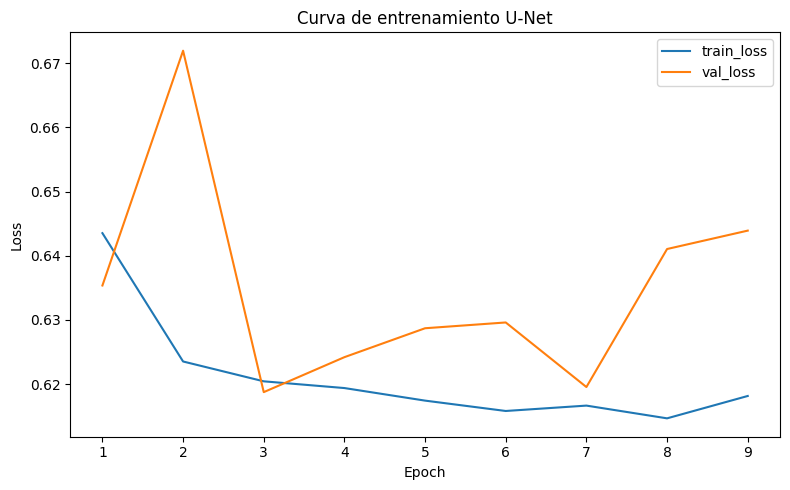

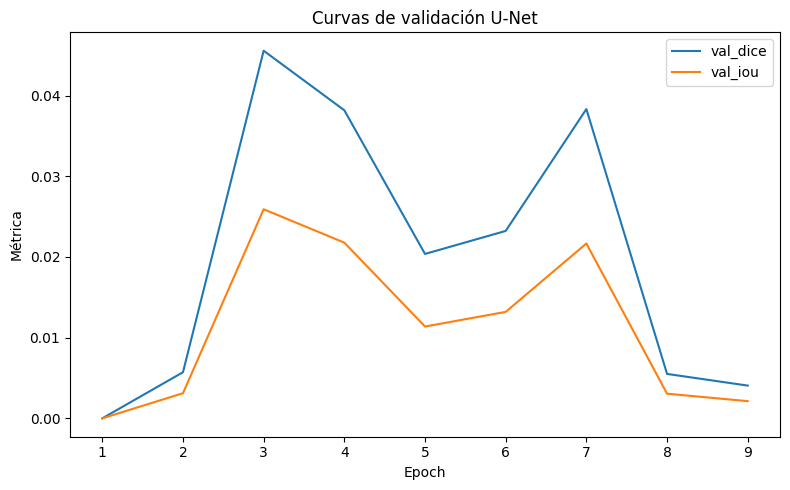

\Resultados en: ..\Data\Datos_U-Net\modelos_unet


In [32]:
df_hist = pd.DataFrame(history)
df_hist.to_csv(DIR_SALIDA / "historial_entrenamiento_unet_piloto.csv", index=False, encoding="utf-8-sig")

# Curvas
plt.figure(figsize=(8, 5))
plt.plot(df_hist["epoch"], df_hist["train_loss"], label="train_loss")
plt.plot(df_hist["epoch"], df_hist["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curva de entrenamiento U-Net")
plt.legend()
plt.tight_layout()
plt.savefig(DIR_SALIDA / "curva_loss_unet.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(df_hist["epoch"], df_hist["val_dice"], label="val_dice")
plt.plot(df_hist["epoch"], df_hist["val_iou"], label="val_iou")
plt.xlabel("Epoch")
plt.ylabel("Métrica")
plt.title("Curvas de validación U-Net")
plt.legend()
plt.tight_layout()
plt.savefig(DIR_SALIDA / "curva_metricas_unet.png", dpi=200)
plt.show()

metadatos = {
    "device": DEVICE,
    "batch_size": BATCH_SIZE,
    "epochs_max": EPOCHS,
    "lr": LR,
    "patience": PATIENCE,
    "train_total": len(train_files),
    "val_total": len(val_files),
    "test_total": len(test_files),
    "canales_usados": canales_usados,
    "canales_excluidos": list(CANALES_EXCLUIR),
    "media_canales": media_canales.tolist(),
    "std_canales": std_canales.tolist(),
    "pos_weight": pos_weight,
    "best_epoch": best_epoch,
    "best_val_dice": best_val_dice,
    "metricas_validacion_final": val_final,
    "metricas_test_final": test_final,
}

with open(DIR_SALIDA / "metadatos_unet.json", "w", encoding="utf-8") as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

print("\Resultados en:", DIR_SALIDA)